# LIBRARY

In [ ]:
# IMPORT LIBRARY
import atoti as tt
import pandas as pd
import numpy as np
from datetime import datetime
from sqlalchemy import create_engine
from sqlalchemy import text
import matplotlib.pyplot as plt

# SAMBUNG KE SUPABASE

In [75]:
# SAMBUNG SUPABASE
DB_USER = "postgres.vhdsgtlkrwvvoquegsqo"
DB_PASSWORD = "Botolair5171"
DB_HOST = "aws-1-ap-northeast-1.pooler.supabase.com"
DB_PORT = "6543"
DB_NAME = "postgres"

# Connection URL
DB_URL = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    f"?sslmode=require"
)

try:
    engine = create_engine(
        DB_URL,
        pool_pre_ping=True
    )

    with engine.connect() as conn:
        version = conn.execute(
            text("SELECT version();")
        ).fetchone()[0]

    print("✅ Koneksi Transaction Pooler berhasil!")
    print(version[:100])

except Exception as e:
    print("❌ Gagal koneksi:")
    print(e)

✅ Koneksi Transaction Pooler berhasil!
PostgreSQL 17.6 on aarch64-unknown-linux-gnu, compiled by gcc (GCC) 15.2.0, 64-bit


# CEK ISI TABEL

In [76]:
# CEK TABEL
with engine.connect() as conn:

    tables = pd.read_sql(
        text("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema='public'
        """),
        conn
    )

tables

,table_name
0,dim_aircraft
1,dim_country
2,dim_location
3,dim_time
4,fact_flight_state
5,fact_flight_state_2024
6,fact_flight_state_2025
7,fact_flight_state_2026
8,fact_flight_state_2023
9,_stg_aircraft


# CEK STRUKTUR TABEL

In [77]:
# CEK STRUKTUR TABEL
for table in [
    "fact_flight_state",
    "dim_aircraft",
    "dim_country",
    "dim_location",
    "dim_time"
]:

    print(table)

    q = f"""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_name='{table}'
    """

    display(pd.read_sql(q, engine))

fact_flight_state


,column_name
0,fact_id
1,aircraft_id
2,country_id
3,time_id
4,location_id
5,baro_altitude
6,velocity
7,vertical_rate
8,on_ground
9,flight_phase


dim_aircraft


,column_name
0,aircraft_id
1,icao24
2,callsign
3,airline_code
4,created_at


dim_country


,column_name
0,country_id
1,country_name
2,region
3,continent


dim_location


,column_name
0,location_id
1,longitude
2,latitude
3,region
4,continent
5,lon_zone
6,lat_zone


dim_time


,column_name
0,time_id
1,datetime_utc
2,date
3,year
4,quarter
5,month
6,month_name
7,day
8,hour
9,day_of_week


# AMBIL DATA DARI TABEL SUPABASE

In [78]:
# AMBIL DATA DARI TABEL
query = """
SELECT

    -- FACT
    f.fact_id,
    f.baro_altitude,
    f.velocity,
    f.vertical_rate,
    f.on_ground,
    f.flight_phase,
    f.scraped_at,
    f.partition_date,

    -- AIRCRAFT
    a.icao24,
    a.callsign,
    a.airline_code,

    -- COUNTRY
    c.country_name AS origin_country,

    -- LOCATION
    l.longitude,
    l.latitude,
    l.region,
    l.continent,
    l.lon_zone,
    l.lat_zone,

    -- TIME
    t.datetime_utc,
    t.date,
    t.year,
    t.quarter,
    t.month,
    t.month_name,
    t.day,
    t.hour,
    t.day_of_week,
    t.time_of_day,
    t.is_weekend

FROM fact_flight_state f

LEFT JOIN dim_aircraft a
ON f.aircraft_id = a.aircraft_id

LEFT JOIN dim_country c
ON f.country_id = c.country_id

LEFT JOIN dim_location l
ON f.location_id = l.location_id

LEFT JOIN dim_time t
ON f.time_id = t.time_id
"""

df = pd.read_sql(
    query,
    engine
)

# CEK DATASET
print(df.head())
print(df.columns.tolist())

print("\nINFO DATASET")
print(df.info())

print("\nUKURAN DATASET")
print(df.shape)

   fact_id  baro_altitude  velocity  vertical_rate  on_ground flight_phase  \
0    49682        7938.54    224.27           0.33      False       Cruise   
1    49683       10983.70    252.30           0.00      False       Cruise   
2    49684         513.15     55.93           1.63      False   Low_Flight   
3    49685        9130.71    245.46           0.00      False       Cruise   
4    49686        9990.89    261.03           0.00      False       Cruise   

                 scraped_at partition_date  icao24 callsign  ...        date  \
0 2024-01-01 18:00:00+00:00     2024-01-01  c06f13    QUE20  ...  2024-01-01   
1 2024-01-02 18:00:00+00:00     2024-01-02  71c531  KAL2015  ...  2024-01-02   
2 2024-01-03 18:00:00+00:00     2024-01-03  c004f5    CFBWU  ...  2024-01-03   
3 2024-01-07 18:00:00+00:00     2024-01-07  aa8ab2   CKS218  ...  2024-01-07   
4 2024-01-09 18:00:00+00:00     2024-01-09  4bb2b2   TKJ51T  ...  2024-01-09   

   year  quarter  month month_name day hour day_of

# PERUBAHAN DIMENSI

In [79]:
# UBAH DIMENSI NUMERIK JADI STRING
df["year"] = df["year"].astype(str)
df["quarter"] = df["quarter"].astype(str)
df["day"] = df["day"].astype(str)
df["hour"] = df["hour"].astype(str)
df["month"] = df["month"].astype(str)

# UBAH BOOLEAN KE INTEGER
df["on_ground_numeric"] = df["on_ground"].astype(int)

# SESI ATOTI

In [80]:
# MEMBUAT SESSION ATOTI
session = tt.Session.start()
print("Session Atoti berhasil dibuat")

Session Atoti berhasil dibuat


# BANGUN TABEL

In [81]:
# MEMBUAT TABLE
table = session.read_pandas(
    df,
    table_name="opensky_flight",
    keys=["fact_id"]
)

print("Table berhasil dibuat")

# MELIHAT STRUKTUR TABLE
print(table)
table.head()

Table berhasil dibuat


,baro_altitude,velocity,vertical_rate,on_ground,flight_phase,scraped_at,partition_date,icao24,callsign,airline_code,...,year,quarter,month,month_name,day,hour,day_of_week,time_of_day,is_weekend,on_ground_numeric
fact_id,,,,,,,,,,,,,,,,,,,,,
50119,5052.06,179.07,-13.0,False,Descent,2026-05-20 12:36:08.626000+00:00,2026-05-20,39de4f,TVF36VX,TVF,...,2026,2,5,May,20,12,Wednesday,Afternoon,False,0
50127,6400.8,153.67,0.0,False,Cruise,2026-05-20 12:36:08.626000+00:00,2026-05-20,a6aeab,N53GA,UNK,...,2026,2,5,May,20,12,Wednesday,Afternoon,False,0
50135,10363.2,229.14,0.33,False,Cruise,2026-05-20 12:36:08.626000+00:00,2026-05-20,8a02ea,LNI352,LNI,...,2026,2,5,May,20,12,Wednesday,Afternoon,False,0
50143,10919.46,244.48,1.3,False,Cruise,2026-05-20 12:36:08.626000+00:00,2026-05-20,ad562a,AVA235,AVA,...,2026,2,5,May,20,12,Wednesday,Afternoon,False,0
50151,8839.2,218.65,0.0,False,Cruise,2026-05-20 12:36:08.626000+00:00,2026-05-20,ad5623,AAL388,AAL,...,2026,2,5,May,20,12,Wednesday,Afternoon,False,0


In [82]:
# CEK KEYS
print("Total Row :", len(df))
print("Unique ICAO :", df["icao24"].nunique())
print("Total Row :", len(df))
print("Unique Fact ID :", df["fact_id"].nunique())

Total Row : 34231
Unique ICAO : 19791
Total Row : 34231
Unique Fact ID : 34231


# BENCHMARK KHUSUS SUPABASE

In [83]:
# BENCHMARK SUPABASE
query = """
SELECT *
FROM fact_flight_state
LIMIT 10000
"""

start = time.perf_counter()

df_test = pd.read_sql(
    query,
    engine
)

end = time.perf_counter()

print(
    "Database Retrieval Time:",
    round(end-start,6),
    "seconds"
)

Database Retrieval Time: 2.312436 seconds


# CUBE

In [84]:
# MEMBUAT CUBE
cube = session.create_cube(table)

print("Cube berhasil dibuat")

Cube berhasil dibuat


# HIERARCHY / DIMENSION

In [85]:
# DEFINISI HIERARCHY & LEVEL
h = cube.hierarchies
l = cube.levels
m = cube.measures

# TIME HIERARCHY
h["Time"] = [
    l[("opensky_flight", "year", "year")],
    l[("opensky_flight", "quarter", "quarter")],
    l[("opensky_flight", "month_name", "month_name")],
    l[("opensky_flight", "day", "day")],
    l[("opensky_flight", "hour", "hour")]
]

# LOCATION HIERARCHY
h["Location"] = [
    l[("opensky_flight", "continent", "continent")],
    l[("opensky_flight", "region", "region")]
]

# COUNTRY HIERARCHY
h["Country"] = [
    l[("opensky_flight", "origin_country", "origin_country")]
]

# GEOGRAPHIC HIERARCHY
h["Geographic"] = [
    l[("opensky_flight", "continent", "continent")],
    l[("opensky_flight", "region", "region")],
    l[("opensky_flight", "origin_country", "origin_country")]
]

# FLIGHT HIERARCHY
h["Flight"] = [
    l[("opensky_flight", "flight_phase", "flight_phase")],
    l[("opensky_flight", "airline_code", "airline_code")],
    l[("opensky_flight", "on_ground", "on_ground")]
]

# AIRLINE HIERARCHY
h["Airline"] = [
    l[("opensky_flight", "airline_code", "airline_code")],
    l[("opensky_flight", "callsign", "callsign")]
]

# TIME ACTIVITIES HIERARCHY
h["Activity"] = [
    l[("opensky_flight", "day_of_week", "day_of_week")],
    l[("opensky_flight", "is_weekend", "is_weekend")],
    l[("opensky_flight", "time_of_day", "time_of_day")]
]
print("Hierarchy berhasil dibuat")


Hierarchy berhasil dibuat


# MEASURE

In [86]:
# Total Flight
m["Total Flights"] = tt.agg.count_distinct(table["icao24"])

# Average Velocity
m["Average Velocity"] = tt.agg.mean(table["velocity"])

# Maximum Velocity
m["Maximum Velocity"] = tt.agg.max(table["velocity"])

# Minimum Velocity
m["Minimum Velocity"] = tt.agg.min(table["velocity"])

# Total Velocity
m["Total Velocity"] = tt.agg.sum(table["velocity"])

# Average Altitude
m["Average Altitude"] = tt.agg.mean(table["baro_altitude"])

# Maximum Altitude
m["Maximum Altitude"] = tt.agg.max(table["baro_altitude"])

# Minimum Altitude
m["Minimum Altitude"] = tt.agg.min(table["baro_altitude"])

# Total Altitude
m["Total Altitude"] = tt.agg.sum(table["baro_altitude"])

# Ground Flight Count
m["Ground Flights"] = tt.agg.sum(table["on_ground_numeric"])

# Airborne Flight
m["Airborne Flights"] = (m["Total Flights"] - m["Ground Flights"])

# Distinct Airline
m["Distinct Airlines"] = tt.agg.count_distinct(table["airline_code"])

# Distinct Country
m["Distinct Countries"] = tt.agg.count_distinct(table["origin_country"])

# Distinct Callsign
m["Distinct Callsigns"] = tt.agg.count_distinct(table["callsign"])

# Average Longitude
m["Average Longitude"] = tt.agg.mean(table["longitude"])

# Maximum Longitude
m["Maximum Longitude"] = tt.agg.max(table["longitude"])

# Minimum Longitude
m["Minimum Longitude"] = tt.agg.min(table["longitude"])

# Average Latitude
m["Average Latitude"] = tt.agg.mean(table["latitude"])

# Maximum Latitude
m["Maximum Latitude"] = tt.agg.max(table["latitude"])

# Minimum Latitude
m["Minimum Latitude"] = tt.agg.min(table["latitude"])

# Average Vertical Rate
m["Average Vertical Rate"] = tt.agg.mean(table["vertical_rate"])

# Maximum Vertical Rate
m["Maximum Vertical Rate"] = tt.agg.max(table["vertical_rate"])

# Minimum Vertical Rate
m["Minimum Vertical Rate"] = tt.agg.min(table["vertical_rate"])

# Flight Traffic Density
m["Flight Traffic Density"] = (m["Total Flights"] / m["Distinct Countries"])

# Airborne Ratio
m["Airborne Ratio"] = (m["Airborne Flights"] / m["Total Flights"])

# Ground Ratio
m["Ground Ratio"] = (m["Ground Flights"] / m["Total Flights"])

# Flight Stability Index
m["Flight Stability Index"] =  (1 / (1 + (m["Average Vertical Rate"] * m["Average Vertical Rate"])))

# Altitude Efficiency Index
m["Altitude Efficiency"] = (m["Average Velocity"] / m["Average Altitude"])

# Regional Traffic Share
m["Regional Traffic Share"] = (m["Total Flights"] / tt.parent_value(m["Total Flights"], degrees={h["Geographic"]: -1}))

# Growth Rate Measure
m["Flight Growth Rate"] = ((m["Airborne Flights"] - m["Ground Flights"]) / m["Total Flights"])

# Moving Average Flights
m["Moving Average Flights"] = ((m["Average Velocity"] + m["Average Altitude"]) / 2)

# Active Airline Ratio
m["Active Airline Ratio"] = (m["Distinct Airlines"] / m["Distinct Countries"])

# Congestion indicator
m["Congestion Indicator"] = (m["Ground Flights"] / m["Airborne Flights"])

# Spatial Coverage Index
m["Spatial Coverage"] = ((m["Maximum Latitude"] - m["Minimum Latitude"]) * (m["Maximum Longitude"] - m["Minimum Longitude"]))

# Flight Activity Score
m["Flight Activity Score"] = (m["Average Velocity"] * m["Airborne Ratio"])

print("Measure berhasil dibuat")

Measure berhasil dibuat


In [87]:
# MENAMPILKAN LINK
session.link

http://localhost:60455

In [88]:
# MENUTUP SESSION
# session.close()

# DATA QUALITY INVESTIGATION
# ANALISIS DISTRIBUSI DATASET PER TAHUN DAN BULAN


In [89]:
df["year"].value_counts()
df.groupby(["year","month_name"])["icao24"].nunique()

year  month_name
2023  April            15
      August           21
      December         19
      February         12
      January          22
      July             15
      June             19
      March            12
      May              19
      November         15
      October          25
      September        13
2024  April            12
      August           16
      December         15
      February         17
      January          15
      July             13
      June             14
      March            15
      May              21
      November         22
      October          24
      September        16
2025  April            24
      August           27
      December         21
      February         27
      January          13
      July             17
      June             18
      March            21
      May              14
      November         12
      October          24
      September        15
2026  May           19420
Name: icao24, dtype: 

In [90]:
print("Total Row :", len(df))
print("Unique ICAO :", df["icao24"].nunique())
df.groupby(["year","month_name"])["icao24"].nunique()

Total Row : 34231
Unique ICAO : 19791


year  month_name
2023  April            15
      August           21
      December         19
      February         12
      January          22
      July             15
      June             19
      March            12
      May              19
      November         15
      October          25
      September        13
2024  April            12
      August           16
      December         15
      February         17
      January          15
      July             13
      June             14
      March            15
      May              21
      November         22
      October          24
      September        16
2025  April            24
      August           27
      December         21
      February         27
      January          13
      July             17
      June             18
      March            21
      May              14
      November         12
      October          24
      September        15
2026  May           19420
Name: icao24, dtype: 

# DATA QUALITY INVESTIGATION
# ANALISIS KATEGORI UNKNOWN


In [91]:
# CEK MISSING VALUE
print(df.isnull().sum().sort_values(ascending=False))

latitude             5
longitude            5
lat_zone             5
lon_zone             5
continent            5
region               5
flight_phase         0
on_ground            0
scraped_at           0
partition_date       0
velocity             0
vertical_rate        0
fact_id              0
baro_altitude        0
airline_code         0
origin_country       0
icao24               0
callsign             0
datetime_utc         0
date                 0
year                 0
quarter              0
month                0
month_name           0
day                  0
hour                 0
day_of_week          0
time_of_day          0
is_weekend           0
on_ground_numeric    0
dtype: int64


In [92]:
# LIHAT DISTRIBUSI NILAI
df["continent"].value_counts(dropna=False)
df["latitude"].value_counts(dropna=False)
df["longitude"].value_counts(dropna=False)
df["lat_zone"].value_counts(dropna=False)
df["lon_zone"].value_counts(dropna=False)
df["region"].value_counts(dropna=False)

region
Europe                 15578
North America          12516
East Asia               1722
South Asia               849
Southeast Asia           849
South America            751
Africa                   697
Oceania                  540
Other                    375
Middle East              276
Russia/Central Asia       73
None                       5
Name: count, dtype: int64

In [93]:
# TAMPILKAN ISI UNKNOWN
print(
    df[df["continent"]=="Unknown"]
    [["origin_country","continent","region", "latitude", "longitude", "lat_zone", "lon_zone"]]
    .drop_duplicates()
)

       origin_country continent region  latitude  longitude lat_zone lon_zone
128             Chile   Unknown  Other     37.98     -11.00   N30-40   W20-10
466           Germany   Unknown  Other     63.92     -26.89   N60-70   W30-20
795            Canada   Unknown  Other     55.61     -12.15   N50-60   W20-10
824           Austria   Unknown  Other     61.68     -24.16   N60-70   W30-20
1008    United States   Unknown  Other     51.87     -12.14   N50-60   W20-10
...               ...       ...    ...       ...        ...      ...      ...
33974          Panama   Unknown  Other     11.78     -84.17   N10-20   W90-80
33998   United States   Unknown  Other     55.01     -11.04   N50-60   W20-10
34059  United Kingdom   Unknown  Other     44.96      43.42   N40-50   E40-50
34115   United States   Unknown  Other     50.59     -13.34   N50-60   W20-10
34172   United States   Unknown  Other     55.38     -12.81   N50-60   W20-10

[368 rows x 7 columns]


In [94]:
# CEK NEGARA PENYUMBANG UNKNOWN TERBANYAK
print(
    df[df["continent"]=="Unknown"]["origin_country"]
    .value_counts()
    .head(20)
)

origin_country
United States                 110
United Kingdom                 32
Russia                         26
Canada                         20
France                         19
Guatemala                      18
Portugal                       15
Germany                        13
China                          11
Kingdom Of The Netherlands     10
Spain                           9
Ireland                         9
Austria                         8
Iceland                         6
Panama                          6
Georgia                         6
Turkey                          6
Denmark                         4
Kazakhstan                      4
India                           3
Name: count, dtype: int64


In [95]:
# HITUNG PERSENTASE UNKNOWN
unknown_pct = (
    (df["continent"]=="Unknown").sum()
    / len(df)
) * 100

print(unknown_pct)

1.0954982325961848


In [96]:
pd.read_sql("""
SELECT DISTINCT
country_name,
continent,
region
FROM dim_country
ORDER BY country_name
""", engine)

,country_name,continent,region
0,Afghanistan,Europe,Europe
1,Algeria,Europe,Europe
2,Angola,Africa,Africa
3,Argentina,Unknown,Other
4,Armenia,Unknown,Other
...,...,...,...
122,Uzbekistan,Asia,Middle East
123,Venezuela,Americas,South America
124,Vietnam,Asia,East Asia
125,Zambia,Africa,Africa


In [97]:
print(
    df[
        df["continent"]=="Unknown"
    ][
        ["origin_country","latitude","longitude"]
    ]
    .head(20)
)

                  origin_country  latitude  longitude
128                        Chile     37.98     -11.00
466                      Germany     63.92     -26.89
795                       Canada     55.61     -12.15
824                      Austria     61.68     -24.16
1008               United States     51.87     -12.14
1262                      Israel     54.26      90.39
1400               United States     52.48     -13.66
1606                     Denmark     64.71     -27.02
1663                        Cuba     14.60     -90.53
1792                      Canada     63.81     -21.03
1898               United States     46.57     -11.86
1947                      Canada     46.69     -10.96
2104  Kingdom Of The Netherlands     52.98     -14.48
2500                      France    -16.04    -148.49
2550                      Russia     54.42      88.56
2597                      Russia     42.02      48.36
2631                      Taiwan     55.97    -171.35
2895               United St

# OLAP - ROLL UP

In [98]:
# 1. Total Flights Per Continent
result_continent = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ]
)

# 2. Flights Per Region
result_region = cube.query(
    m["Total Flights"],
    m["Flight Traffic Density"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","region","region")]
    ]
)

# 3. Flights Per Country
result_country = cube.query(
    m["Total Flights"],
    m["Distinct Airlines"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","origin_country","origin_country")]
    ]
)

# 4. Flights Yearly
result_year = cube.query(
    m["Total Flights"],
    m["Airborne Ratio"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","year","year")]
    ]
)

# 5. Flights Quarter Per Year
result_quarter = cube.query(
    m["Total Flights"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","quarter","quarter")]
    ]
)

# 6. Flights Monthly
result_month = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","month_name","month_name")]
    ]
)

# 7. Flights Time Of Day
result_timeofday = cube.query(
    m["Total Flights"],
    m["Flight Activity Score"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","time_of_day","time_of_day")]
    ]
)

# 8. Flight Phase
result_phase = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","flight_phase","flight_phase")]
    ]
)

# 9. Active Airline
result_airline = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ]
)

# 10. Flights Weekend VS Weekday
result_weekend = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","is_weekend","is_weekend")]
    ]
)

# 11. Continent and Year
result_continent_year = cube.query(
    m["Total Flights"],
    m["Airborne Ratio"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","year","year")]
    ]
)

# 12. Flights Geographic
result_geo = cube.query(
    m["Total Flights"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")],
        l[("opensky_flight","origin_country","origin_country")]
    ]
)

from IPython.display import display

display(result_continent)
display(result_region)
display(result_country)
display(result_year)
display(result_quarter)
display(result_month)
display(result_timeofday)
display(result_phase)
display(result_airline)
display(result_weekend)
display(result_continent_year)
display(result_geo)

,Total Flights,Average Velocity,Average Altitude
continent,,,
Africa,545,183.64,"7,529.52"
Americas,"8,604",143.64,"5,386.39"
Asia,"2,531",177.41,"6,633.86"
Europe,"8,014",159.27,"6,408.14"
N/A,5,134.69,"4,744.21"
Oceania,364,120.07,"4,360.54"
Unknown,333,204.21,"9,545.03"


,Total Flights,Flight Traffic Density,Congestion Indicator
region,,,
Africa,545,8.13,.06
East Asia,"1,111",37.03,.29
Europe,"8,014",94.28,.19
Middle East,225,4.89,.05
N/A,5,1.67,.00
North America,"8,065",217.97,.21
Oceania,364,22.75,.94
Other,333,7.09,.06
Russia/Central Asia,60,15.00,.00


,Total Flights,Distinct Airlines,Average Velocity
origin_country,,,
Afghanistan,2,2,182.99
Algeria,26,2,207.25
Angola,5,2,187.95
Argentina,48,12,158.92
Armenia,2,1,226.37
...,...,...,...
Uzbekistan,17,5,208.28
Venezuela,1,1,154.34
Vietnam,30,4,202.42


,Total Flights,Airborne Ratio,Average Altitude
year,,,
2023,204,.88,"5,587.05"
2024,196,.91,"6,410.20"
2025,229,.86,"5,735.83"
2026,"19,420",.83,"6,064.77"


Total Flights Flight Activity Score
year quarter                                    
2023 1                  46                147.37
     2                  53                135.61
     3                  49                127.63
     4                  59                117.49
2024 1                  47                156.44
     2                  47                141.68
     3                  45                163.84
     4                  59                142.80
2025 1                  61                116.57
     2                  56                158.38
     3                  58                116.16
     4                  57                132.25
2026 2              19,420                129.72

...

,Total Flights,Average Velocity,Average Altitude
flight_phase,,,
Climb,"3,550",202.22,"7,346.04"
Cruise,"8,583",228.83,"10,734.08"
Descent,"3,007",196.87,"6,736.39"
Ground,"3,333",9.96,15.96
Landing,"2,802",91.39,"1,144.03"
Low_Flight,"4,579",71.79,"1,436.90"
Takeoff,"1,529",93.16,"1,318.20"


,Total Flights,Average Velocity,Flight Activity Score
airline_code,,,
AAB,2,68.94,34.47
AAC,1,63.13,63.13
AAH,1,190.55,190.55
AAL,596,184.10,146.11
AAN,4,183.45,183.45
...,...,...,...
ZUP,1,61.11,61.11
ZUS,1,39.94,39.94
ZUW,1,79.90,79.90


,Total Flights,Average Velocity,Congestion Indicator
is_weekend,,,
false,"14,413",151.36,.16
true,"8,856",161.97,.17


Total Flights Airborne Ratio
continent year                             
Africa    2023             2           1.00
          2024             4           1.00
          2025             4           1.00
          2026           537            .94
Americas  2023           151            .91
          2024           130            .91
          2025           157            .86
          2026         8,318            .83
Asia      2023            31            .74
          2024            31            .97
          2025            38            .95
          2026         2,472            .87
Europe    2023             7            .71
          2024            15            .73
          2025            15            .80
          2026         7,997            .84
N/A       2026             5           1.00
Oceania   2023            13            .85
          2024            15            .93
          2025            14            .71
          2026           328            .48
Unknown   2024             1           1.00
          2025             1           1.00
          2026           331            .95

Total Flights
continent region origin_country                    
Africa    Africa Algeria                          1
                 Angola                           5
                 Argentina                        2
                 Australia                        1
                 Austria                         17
...                                             ...
Unknown   Other  United Arab Emirates             2
                 United Kingdom                  27
                 United States                   97
                 Uzbekistan                       2
                 Vietnam                          1

[436 rows x 1 columns]

# OLAP - DRILL DOWN

In [99]:
# 1. Time Detail Analysis
result_time_drill = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","quarter","quarter")],
        l[("opensky_flight","month_name","month_name")],
        l[("opensky_flight","day","day")],
        l[("opensky_flight","hour","hour")]
    ]
)

# 2. Geographic Detail
result_geo_drill = cube.query(
    m["Total Flights"],
    m["Regional Traffic Share"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")],
        l[("opensky_flight","origin_country","origin_country")]
    ]
)

# 3. Flight Operational Analysis
result_flight_drill = cube.query(
    m["Total Flights"],
    m["Airborne Ratio"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","flight_phase","flight_phase")],
        l[("opensky_flight","airline_code","airline_code")],
        l[("opensky_flight","on_ground","on_ground")]
    ]
)

# 4. Airline Detail
result_airline_drill = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")],
        l[("opensky_flight","callsign","callsign")]
    ]
)

# 5. Activity Pattern Analysis
result_activity_drill = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","day_of_week","day_of_week")],
        l[("opensky_flight","is_weekend","is_weekend")],
        l[("opensky_flight","time_of_day","time_of_day")]
    ]
)

# 6. Spatio Temporal Anslysis
result_spatiotemporal = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")]
    ]
)

# 7. Flight Performance
result_performance = cube.query(
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    m["Flight Growth Rate"],
    levels=[
        l[("opensky_flight","flight_phase","flight_phase")],
        l[("opensky_flight","origin_country","origin_country")]
    ]
)

# 8. Spatial Detail
result_spatial = cube.query(
    m["Spatial Coverage"],
    m["Average Latitude"],
    m["Average Longitude"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")]
    ]
)

from IPython.display import display

display(result_time_drill)
display(result_geo_drill)
display(result_flight_drill)
display(result_airline_drill)
display(result_activity_drill)
display(result_spatiotemporal)
display(result_performance)
display(result_spatial)

Total Flights Average Velocity  \
year quarter month_name day hour                                  
2023 1       February   10  5                1           243.36   
                        12  17               1           198.10   
                        13  16               1            -2.65   
                        18  17               1           182.16   
                            4                1           203.00   
...                                        ...              ...   
2026 2       May        20  12           9,698           153.82   
                            13          10,403           148.89   
                        24  10           8,492           163.29   
                            6                1              .00   
                            9              258            98.93   

                                 Average Altitude  
year quarter month_name day hour                   
2023 1       February   10  5            9,466.73  
                        12  17           4,666.69  
                        13  16                .00  
                        18  17           3,386.04  
                            4            6,622.10  
...                                           ...  
2026 2       May        20  12           5,993.28  
                            13           5,743.44  
                        24  10           6,409.65  
                            6                 .00  
                            9            4,073.16  

[640 rows x 3 columns]

Total Flights Regional Traffic Share  \
continent region origin_country                                              
Africa    Africa Algeria                          1                   1.00   
                 Angola                           5                   1.00   
                 Argentina                        2                   1.00   
                 Australia                        1                   1.00   
                 Austria                         17                   1.00   
...                                             ...                    ...   
Unknown   Other  United Arab Emirates             2                   1.00   
                 United Kingdom                  27                   1.00   
                 United States                   97                   1.00   
                 Uzbekistan                       2                   1.00   
                 Vietnam                          1                   1.00   

                                      Flight Activity Score  
continent region origin_country                              
Africa    Africa Algeria                             243.51  
                 Angola                              187.95  
                 Argentina                           241.42  
                 Australia                           195.19  
                 Austria                             185.42  
...                                                     ...  
Unknown   Other  United Arab Emirates                255.93  
                 United Kingdom                      235.95  
                 United States                       205.89  
                 Uzbekistan                           27.52  
                 Vietnam                             234.99  

[436 rows x 3 columns]

Total Flights Airborne Ratio  \
flight_phase airline_code on_ground                                
Climb        AAB          false                 1           1.00   
             AAL          false               151           1.00   
             AAN          false                 1           1.00   
             AAO          false                 1           1.00   
             AAR          false                 7           1.00   
...                                           ...            ...   
Takeoff      YLP          false                 1           1.00   
             ZSH          false                 1           1.00   
             ZSI          false                 1           1.00   
             ZUJ          false                 1           1.00   
             ZUN          false                 1           1.00   

                                    Congestion Indicator  
flight_phase airline_code on_ground                       
Climb        AAB          false                      .00  
             AAL          false                      .00  
             AAN          false                      .00  
             AAO          false                      .00  
             AAR          false                      .00  
...                                                  ...  
Takeoff      YLP          false                      .00  
             ZSH          false                      .00  
             ZSI          false                      .00  
             ZUJ          false                      .00  
             ZUN          false                      .00  

[4927 rows x 3 columns]

Total Flights Average Velocity Flight Activity Score
airline_code callsign                                                     
AAB          AAB42N               1           103.39                103.39
             AAB45Z               1              .06                   .00
AAC          AAC311               1            63.13                 63.13
AAH          AAH223               1           190.55                190.55
AAL          AAL1                 1           146.83                146.83
...                             ...              ...                   ...
ZUS          ZUSLG                1            39.94                 39.94
ZUW          ZUWRV                1            79.90                 79.90
ZUY          ZUYXZ                1            45.89                 45.89
ZXP          ZXP02                1            61.18                 61.18
             ZXP25                1            51.95                 51.95

[19084 rows x 3 columns]

Total Flights Average Velocity  \
day_of_week is_weekend time_of_day                                  
Friday      false      Afternoon              28           166.17   
                       Evening                29           137.44   
                       Morning                26           149.43   
                       Night                  23           187.85   
Monday      false      Afternoon              29           155.81   
                       Evening                23           153.02   
                       Morning                21           155.44   
                       Night                  23           145.41   
Saturday    true       Afternoon              23           149.74   
                       Evening                21           154.93   
                       Morning                22           148.16   
                       Night                  30           150.11   
Sunday      true       Afternoon              21           175.55   
                       Evening                18           171.81   
                       Morning             8,721           162.02   
                       Night                  20           163.58   
Thursday    false      Afternoon              27           121.76   
                       Evening                22           155.97   
                       Morning                22           112.76   
                       Night                  18           156.16   
Tuesday     false      Afternoon              21           180.99   
                       Evening                28           173.16   
                       Morning                14           162.60   
                       Night                  10           123.53   
Wednesday   false      Afternoon          14,116           151.27   
                       Evening                21           145.54   
                       Morning                29           181.98   
                       Night                  30           166.74   

                                   Congestion Indicator  
day_of_week is_weekend time_of_day                       
Friday      false      Afternoon                    .12  
                       Evening                      .12  
                       Morning                      .18  
                       Night                        .05  
Monday      false      Afternoon                    .16  
                       Evening                      .21  
                       Morning                      .11  
                       Night                        .28  
Saturday    true       Afternoon                    .10  
                       Evening                      .17  
                       Morning                      .10  
                       Night                        .07  
Sunday      true       Afternoon                    .05  
                       Evening                      .12  
                       Morning                      .17  
                       Night                        .11  
Thursday    false      Afternoon                    .23  
                       Evening                      .16  
                       Morning                      .29  
                       Night                        .12  
Tuesday     false      Afternoon                    .11  
                       Evening                      .12  
                       Morning                      .08  
                       Night                        .11  
Wednesday   false      Afternoon                    .16  
                       Evening                      .11  
                       Morning                      .12  
                       Night                        .15

Total Flights Average Velocity  \
year continent region                                               
2023 Africa    Africa                          2           205.02   
     Americas  North America                 146           152.30   
               South America                   5           201.22   
     Asia      East Asia                      14           135.64   
               Middle East                     1           279.30   
               Russia/Central Asia             1             6.85   
               South Asia                      9           194.80   
               Southeast Asia                  6           121.56   
     Europe    Europe                          7           153.83   
     Oceania   Oceania                        13            75.88   
2024 Africa    Africa                          4           206.27   
     Americas  North America                 127           162.64   
               South America                   3           220.86   
     Asia      East Asia                      13           194.19   
               Middle East                     3           249.62   
               Russia/Central Asia             1           214.32   
               South Asia                      8           179.71   
               Southeast Asia                  6           176.31   
     Europe    Europe                         15           191.14   
     Oceania   Oceania                        15            86.95   
     Unknown   Other                           1           127.86   
2025 Africa    Africa                          4           191.21   
     Americas  North America                 150           139.16   
               South America                   7           210.30   
     Asia      East Asia                      14           191.78   
               Middle East                     5           254.99   
               South Asia                     12           160.55   
               Southeast Asia                  7           179.51   
     Europe    Europe                         15           133.60   
     Oceania   Oceania                        14           127.42   
     Unknown   Other                           1           259.09   
2026 Africa    Africa                        537           183.39   
     Americas  North America               7,785           141.65   
               South America                 541           170.69   
     Asia      East Asia                   1,086           167.54   
               Middle East                   217           194.51   
               Russia/Central Asia            58           212.79   
               South Asia                    555           181.96   
               Southeast Asia                600           184.34   
     Europe    Europe                      7,997           159.26   
     N/A       N/A                             5           134.69   
     Oceania   Oceania                       328           122.02   
     Unknown   Other                         331           204.27   

                                   Flight Activity Score  
year continent region                                     
2023 Africa    Africa                             205.02  
     Americas  North America                      138.74  
               South America                      201.22  
     Asia      East Asia                           96.88  
               Middle East                        279.30  
               Russia/Central Asia                  6.85  
               South Asia                         173.16  
               Southeast Asia                      60.78  
     Europe    Europe                             109.88  
     Oceania   Oceania                             64.20  
2024 Africa    Africa                             206.27  
     Americas  North America                      147.27  
               South America                      220.86  
     Asia      East Asia                    

Flight Stability Index Altitude Efficiency  \
flight_phase origin_country                                                    
Climb        Algeria                                 .01                 .03   
             Angola                                  .01                 .02   
             Argentina                               .01                 .03   
             Australia                               .02                 .03   
             Austria                                 .01                 .03   
...                                                  ...                 ...   
Takeoff      United Arab Emirates                    .01                 .08   
             United Kingdom                          .02                 .07   
             United States                           .02                 .07   
             Vietnam                                 .01                 .07   
             Zambia                                  .01                 .05   

                                  Flight Growth Rate  
flight_phase origin_country                           
Climb        Algeria                            1.00  
             Angola                             1.00  
             Argentina                          1.00  
             Australia                          1.00  
             Austria                            1.00  
...                                              ...  
Takeoff      United Arab Emirates               1.00  
             United Kingdom                     1.00  
             United States                      1.00  
             Vietnam                            1.00  
             Zambia                             1.00  

[605 rows x 3 columns]

Spatial Coverage Average Latitude  \
continent region                                                  
Africa    Africa                      4,024.96            14.80   
Americas  North America               6,130.16            37.49   
          South America               2,547.20           -17.88   
Asia      East Asia                   1,067.20            31.81   
          Middle East                   381.73            37.61   
          Russia/Central Asia           532.15            59.56   
          South Asia                    780.46            22.41   
          Southeast Asia                787.54             8.14   
Europe    Europe                      1,743.06            47.31   
Oceania   Oceania                     2,147.38           -33.74   
Unknown   Other                      33,368.92            45.38   

                              Average Longitude  
continent region                                 
Africa    Africa                          16.13  
Americas  North America                  -88.91  
          South America                  -54.63  
Asia      East Asia                      128.64  
          Middle East                     43.13  
          Russia/Central Asia             60.38  
          South Asia                      78.81  
          Southeast Asia                 106.96  
Europe    Europe                           8.69  
Oceania   Oceania                        146.36  
Unknown   Other                          -11.81

# OLAP - SLICE

In [100]:
# 1. Analisis Flight 2025
result_slice_year = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        l[("opensky_flight","year","year")] == "2025"
    )
)

# 2. Analisis Eropa Saja
result_slice_europe = cube.query(
    m["Total Flights"],
    m["Average Altitude"],
    m["Airborne Ratio"],
    levels=[
        l[("opensky_flight","origin_country","origin_country")]
    ],
    filter=(
        l[("opensky_flight","continent","continent")]=="Europe"
    )
)

# 3. Analisis Cruise Flight
result_slice_cruise = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        l[("opensky_flight","flight_phase","flight_phase")]=="Cruise"
    )
)

# 4. Weekend Traffic
result_slice_weekend = cube.query(
    m["Total Flights"],
    m["Congestion Indicator"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","time_of_day","time_of_day")]
    ],
    filter=(
        l[("opensky_flight","is_weekend","is_weekend")] == True
    )
)

# 5. Analisis Delta Airlines
result_slice_airline = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","flight_phase","flight_phase")]
    ],
    filter=(
        l[("opensky_flight","airline_code","airline_code")]=="DAL"
    )
)

# 6. Analisis Night Flight
result_slice_night = cube.query(
    m["Total Flights"],
    m["Flight Stability Index"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","origin_country","origin_country")]
    ],
    filter=(
        l[("opensky_flight","time_of_day","time_of_day")]=="Night"
    )
)

# 7. Analisis USA
result_slice_usa = cube.query(
    m["Total Flights"],
    m["Distinct Airlines"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","month_name","month_name")]
    ],
    filter=(
        l[("opensky_flight","origin_country","origin_country")]=="United States"
    )
)

# 8. Ground Operations
result_slice_ground = cube.query(
    m["Ground Flights"],
    m["Congestion Indicator"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        l[("opensky_flight","on_ground","on_ground")] == True
    )
)

# 9. Analisis High Altitude Traffic
result_high_altitude = cube.query(
    m["Total Flights"],
    m["Average Altitude"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        m["Average Altitude"] > 10000
    )
)

# 10. Analisis High Congestion
result_congestion = cube.query(
    m["Total Flights"],
    m["Congestion Indicator"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","region","region")]
    ],
    filter=(
        m["Congestion Indicator"] > 0.5
    )
)

# 11. Analisis Fast Flight
result_fastflight = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        m["Average Velocity"] > 250
    )
)

# 12. Spatial Coverage
result_spatial = cube.query(
    m["Spatial Coverage"],
    m["Total Flights"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        m["Spatial Coverage"] > 1000
    )
)

# 13. Analisis Elite Air Traffic
result_elite = cube.query(
    m["Total Flights"],
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (m["Flight Activity Score"] > 150) &
        (m["Flight Stability Index"] > 0.8)
    )
)

from IPython.display import display

display(result_slice_year)
display(result_slice_europe)
display(result_slice_cruise)
display(result_slice_weekend)
display(result_slice_airline)
display(result_slice_night)
display(result_slice_usa)
display(result_slice_ground)

display(result_high_altitude)
display(result_congestion)
display(result_fastflight)
display(result_spatial)
display(result_elite)

,Total Flights,Average Velocity,Flight Activity Score
continent,,,
Africa,4,191.21,191.21
Americas,157,142.25,122.32
Asia,38,187.76,177.87
Europe,15,133.60,106.88
Oceania,14,127.42,91.02
Unknown,1,259.09,259.09


,Total Flights,Average Altitude,Airborne Ratio
origin_country,,,
Algeria,25,"8,475.47",.92
Argentina,1,"10,058.40",1.00
Australia,4,"5,798.82",.50
Austria,302,"6,139.78",.83
Azerbaijan,5,"8,090.54",1.00
...,...,...,...
United Arab Emirates,111,"10,160.78",.94
United Kingdom,"1,182","5,766.69",.87
United States,345,"7,033.50",.89


,Total Flights,Average Velocity,Average Altitude
airline_code,,,
AAL,372,228.58,"10,467.62"
AAN,2,219.16,"12,700.00"
AAO,2,174.53,"10,515.60"
AAR,20,241.35,"10,869.22"
AAW,1,202.69,"10,363.20"
...,...,...,...
YRS,1,290.55,"12,496.80"
YZR,3,180.43,"9,881.62"
ZSN,1,113.55,"7,315.20"


,Total Flights,Congestion Indicator,Flight Activity Score
time_of_day,,,
Afternoon,44,.07,151.01
Evening,39,.15,141.86
Morning,"8,738",.17,137.97
Night,50,.09,143.05


,Total Flights,Average Velocity,Average Altitude
flight_phase,,,
Climb,166,214.47,"7,273.48"
Cruise,331,231.25,"10,396.80"
Descent,101,212.15,"6,721.29"
Ground,167,6.90,-.31
Landing,49,110.09,"1,431.68"
Low_Flight,27,124.00,"1,814.48"
Takeoff,43,123.91,"1,462.69"


...

,Total Flights,Average Altitude,Average Velocity


,Total Flights,Congestion Indicator,Flight Activity Score
region,,,
Oceania,364,.94,62.02


,Total Flights,Average Velocity,Average Altitude
airline_code,,,
ANS,1,252.94,"10,888.98"
APO,1,261.77,"10,058.40"
APZ,3,250.77,"10,731.50"
ATC,1,255.95,"10,363.20"
CPI,2,251.14,"10,911.84"
CYZ,1,257.10,"9,855.20"
DSO,1,251.63,"11,887.20"
FYG,1,255.67,"12,496.80"
GZP,2,410.15,"10,363.20"


,Spatial Coverage,Total Flights
continent,,
Africa,"4,024.96",545
Americas,"15,079.44","8,604"
Asia,"8,057.12","2,531"
Europe,"1,743.06","8,014"
Oceania,"2,147.38",364
Unknown,"33,368.92",333


Total Flights Flight Stability Index  \
continent airline_code                                        
Africa    ADN                      1                    .90   
          AIC                      8                    .86   
          ARG                      2                   1.00   
          ATC                      1                    .90   
          AXY                      1                    .90   
...                              ...                    ...   
Unknown   VJT                      1                    .90   
          VPC                      1                    .97   
          WFL                      1                   1.00   
          WJA                      1                    .90   
          YZR                      1                   1.00   

                       Altitude Efficiency Flight Activity Score  
continent airline_code                                            
Africa    ADN                          .02                193.24  
          AIC                          .02                220.10  
          ARG                          .02                241.42  
          ATC                          .02                255.95  
          AXY                          .02                229.71  
...                                    ...                   ...  
Unknown   VJT                          .02                235.00  
          VPC                          .02                241.04  
          WFL                          .02                238.46  
          WJA                          .02                216.04  
          YZR                          .02                220.02  

[446 rows x 4 columns]

# OLAP - DICE

In [101]:
# 1. Analisis Europe 2025
result_dice_europe2025 = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    levels=[
        l[("opensky_flight","region","region")]
    ],
    filter=(
        (l[("opensky_flight","year","year")]=="2025")
        &
        (l[("opensky_flight","continent","continent")]=="Europe")
    )
)

# 2. Analisis Airline, Weekend, dan Cruise Flights
result_dice_ops = cube.query(
    m["Total Flights"],
    m["Airborne Ratio"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
        &
        (l[("opensky_flight","is_weekend","is_weekend")] == True)
    )
)

# 3. Analisis North America Saat Malam
result_dice_geo_time = cube.query(
    m["Total Flights"],
    m["Congestion Indicator"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","origin_country","origin_country")]
    ],
    filter=(
        (l[("opensky_flight","continent","continent")]=="Americas")
        &
        (l[("opensky_flight","time_of_day","time_of_day")]=="Night")
    )
)

# 4. Analisis USA Saat Cruise
result_dice_country_airline = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Stability Index"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (l[("opensky_flight","origin_country","origin_country")]=="United States")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
    )
)

# 5. Analisis Aktivitas Penerbangan Weekend Afternoon
result_dice_activity = cube.query(
    m["Total Flights"],
    m["Flight Activity Score"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ],
    filter=(
        (l[("opensky_flight","is_weekend","is_weekend")] == True)
        &
        (l[("opensky_flight","time_of_day","time_of_day")]=="Afternoon")
    )
)

# 6. Analisis Penerbangan Eropa Saat Fase Cruise
result_dice_airline_geo = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Altitude Efficiency"],
    levels=[
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (l[("opensky_flight","continent","continent")]=="Europe")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
    )
)

# 7. Analisis Elite Flight Traffic
result_elite_cube = cube.query(
    m["Total Flights"],
    m["Flight Activity Score"],
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","airline_code","airline_code")]
    ],
    filter=(
        (l[("opensky_flight","year","year")]=="2025")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
        &
        (m["Average Velocity"] > 200)
    )
)

# 8. Deteksi Air Traffic Hotspot
result_hotspot = cube.query(
    m["Total Flights"],
    m["Regional Traffic Share"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")]
    ],
    filter=(
        (l[("opensky_flight","time_of_day","time_of_day")]=="Afternoon")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Ground")
        &
        (m["Congestion Indicator"] > 0.4)
    )
)

# 9. Spatio Temporal Flight Intelligence
result_spatiotemporal = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Flight Activity Score"],
    m["Spatial Coverage"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")]
    ],
    filter=(
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
        &
        (l[("opensky_flight","is_weekend","is_weekend")] == False)
        &
        (m["Average Altitude"] > 8000)
    )
)

# 10. Global Aviation Performance Benchmark
result_benchmark = cube.query(
    m["Total Flights"],
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    m["Active Airline Ratio"],
    m["Flight Growth Rate"],
    levels=[
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","origin_country","origin_country")]
    ],
    filter=(
        (l[("opensky_flight","year","year")]=="2025")
        &
        (l[("opensky_flight","flight_phase","flight_phase")]=="Cruise")
        &
        (l[("opensky_flight","time_of_day","time_of_day")]=="Morning")
        &
        (m["Flight Stability Index"] > 0.85)
    )
)

from IPython.display import display

display(result_dice_europe2025)
display(result_dice_ops)
display(result_dice_geo_time)
display(result_dice_country_airline)
display(result_dice_activity)
display(result_dice_airline_geo)
display(result_elite_cube)
display(result_hotspot)
display(result_spatiotemporal)
display(result_benchmark)

,Total Flights,Average Velocity,Average Altitude
region,,,
Europe,15,133.60,"4,816.73"


,Total Flights,Airborne Ratio,Flight Activity Score
airline_code,,,
AAL,94,1.00,237.50
AAN,2,1.00,218.28
AAR,8,1.00,244.83
AAY,2,1.00,205.50
ABD,1,1.00,253.28
...,...,...,...
XAX,1,1.00,223.88
XBJ,1,1.00,215.58
YZR,3,1.00,170.53


,Total Flights,Congestion Indicator,Average Velocity
origin_country,,,
Brazil,1,.00,236.66
Canada,7,.17,128.41
Chile,1,.00,210.75
Mexico,2,.00,232.57
Turkey,1,.00,254.80
United Kingdom,3,.50,163.39
United States,93,.12,152.83


,Total Flights,Average Velocity,Flight Stability Index
airline_code,,,
AAL,372,228.58,1.00
AAY,20,217.13,1.00
ABX,13,229.95,1.00
AER,2,123.16,.90
AIP,1,95.74,.90
...,...,...,...
WMN,2,234.84,.90
WSN,1,175.16,1.00
XAA,1,208.95,.90


,Total Flights,Flight Activity Score,Congestion Indicator
continent,,,
Africa,1,187.18,.00
Americas,34,144.55,.06
Asia,4,195.48,.00
Europe,1,.00,∞
Oceania,4,222.79,.00


,Total Flights,Average Velocity,Altitude Efficiency
airline_code,,,
AAL,37,240.82,.02
AAN,2,219.16,.02
AAO,2,174.53,.02
AAR,2,249.47,.02
ABD,1,236.12,.02
...,...,...,...
WMT,32,234.06,.02
WUK,13,234.55,.02
WZZ,37,226.73,.02


Total Flights Flight Activity Score  \
continent airline_code                                       
Africa    TVS                      1                260.25   
Americas  AAL                      3                237.44   
          ACA                      1                260.55   
          ASA                      3                225.85   
          BOV                      1                253.53   
          DAL                     10                222.08   
          DHR                      1                213.26   
          EDV                      1                248.99   
          EJA                      2                226.53   
          FDX                      2                217.05   
          GLO                      1                236.66   
          JBU                      1                259.10   
          JIA                      1                256.19   
          KLM                      1                258.49   
          LRC                      1                242.18   
          PAT                      1                271.65   
          POE                      1                214.94   
          SKW                      2                222.42   
          SWA                      7                238.59   
          SWR                      1                261.65   
          UAL                      8                242.36   
          UNK                      2                223.28   
          UPS                      1                277.46   
          VOI                      1                227.06   
          WJA                      1                204.60   
Asia      AFL                      1                261.11   
          AIQ                      1                239.54   
          CAL                      1                246.62   
          CSS                      1                234.12   
          DHX                      1                222.12   
          IGO                      1                254.68   
          JNA                      1                221.96   
          KAL                      1                230.69   
          KLM                      1                243.62   
          PTA                      1                247.96   
          SDM                      1                237.14   
          THY                      1                223.13   
          TNU                      1                230.82   
          UNK                      2                235.04   
Europe    AZG                      1                239.40   
          IGA                      1                207.94   
          SXS                      2                262.71   
Oceania   ANZ                      1                211.80   
          CES                      1                250.50   
          QFA                      1                231.82   
Unknown   DAL                      1                259.09   

                       Flight Stability Index Altitude Efficiency  
continent airline_code                                             
Africa    TVS                            1.00                 .02  
Americas  AAL                            1.00                 .02  
          ACA                             .90                 .02  
          ASA                            1.00                 .02  
          BOV                            1.00                 .02  
          DAL                            1.00                 .02  
          DHR                             .90                 .02  
          EDV                             .90                 .02  
          EJA                            1.00                 .02  
          FDX                            1.00                 .02  
          GLO                            1.00                 .03  
          JBU                            1.00                 .02  
          JIA                            1.00                 .02  
          KLM             

Total Flights Regional Traffic Share  \
continent region                                                
Africa    Africa                    17                   1.00   
Americas  North America          1,079                   1.00   
          South America             36                   1.00   
Asia      East Asia                 98                   1.00   
          South Asia                33                   1.00   
          Southeast Asia            12                   1.00   
Europe    Europe                   669                   1.00   
Oceania   Oceania                   73                   1.00   

                         Congestion Indicator  
continent region                               
Africa    Africa                         7.50  
Americas  North America                 32.72  
          South America                  6.20  
Asia      East Asia                     31.67  
          South Asia                        ∞  
          Southeast Asia                11.00  
Europe    Europe                        16.61  
Oceania   Oceania                           ∞

Total Flights Average Velocity  \
year continent region                                               
2023 Americas  North America                  40           223.45   
               South America                   3           246.75   
     Asia      East Asia                       3           230.79   
               South Asia                      2           237.13   
               Southeast Asia                  2           231.01   
     Europe    Europe                          2           248.74   
2024 Africa    Africa                          3           243.33   
     Americas  North America                  42           231.40   
               South America                   2           230.49   
     Asia      East Asia                       5           242.14   
               Middle East                     3           249.62   
               Russia/Central Asia             1           214.32   
               South Asia                      3           256.15   
               Southeast Asia                  1           227.22   
     Europe    Europe                          9           259.99   
2025 Africa    Africa                          1           260.25   
     Americas  North America                  37           230.20   
               South America                   3           249.56   
     Asia      East Asia                       7           232.92   
               Middle East                     1           222.61   
               South Asia                      4           243.26   
     Europe    Europe                          4           243.19   
     Oceania   Oceania                         2           241.16   
2026 Africa    Africa                        136           228.33   
     Americas  North America               2,368           222.94   
               South America                 190           219.15   
     Asia      East Asia                     236           237.40   
               Middle East                   101           215.26   
               Russia/Central Asia            23           239.48   
               South Asia                    126           242.82   
               Southeast Asia                132           236.23   
     Europe    Europe                      2,258           229.75   
     N/A       N/A                             1           187.66   
     Oceania   Oceania                        43           225.19   
     Unknown   Other                         138           225.41   

                                   Flight Activity Score Spatial Coverage  
year continent region                                                      
2023 Americas  North America                      223.45         2,005.14  
               South America                      246.75            39.10  
     Asia      East Asia                          230.79           351.01  
               South Asia                         237.13             9.36  
               Southeast Asia                     231.01             8.15  
     Europe    Europe                             248.74            62.43  
2024 Africa    Africa                             243.33           645.53  
     Americas  North America                      231.40         1,316.69  
               South America                      230.49            26.93  
     Asia      East Asia                          242.14           214.75  
               Middle East                        249.62             2.98  
               Russia/Central Asia                214.32              .00  
               South Asia                         256.15           149.81  
               Southeast Asia                     227.22              .00  
     Europe    Europe                             259.99           640.25  
2025 Africa    Africa                             260.25              .00  
     Americas  North America                      230.20         4,207.49  
               South America         

Total Flights Flight Stability Index  \
continent origin_country                                           
Americas  United States                 5                   1.00   
Asia      Germany                       1                   1.00   
          Republic Of Korea             1                   1.00   
          Russia                        2                   1.00   
Europe    United Kingdom                1                   1.00   
Oceania   Australia                     1                    .90   

                            Altitude Efficiency Active Airline Ratio  \
continent origin_country                                               
Americas  United States                     .02                 4.00   
Asia      Germany                           .02                 1.00   
          Republic Of Korea                 .02                 1.00   
          Russia                            .02                 2.00   
Europe    United Kingdom                    .02                 1.00   
Oceania   Australia                         .02                 1.00   

                            Flight Growth Rate  
continent origin_country                        
Americas  United States                   1.00  
Asia      Germany                         1.00  
          Republic Of Korea               1.00  
          Russia                          1.00  
Europe    United Kingdom                  1.00  
Oceania   Australia                       1.00

# VISUALISASI ROLL UP

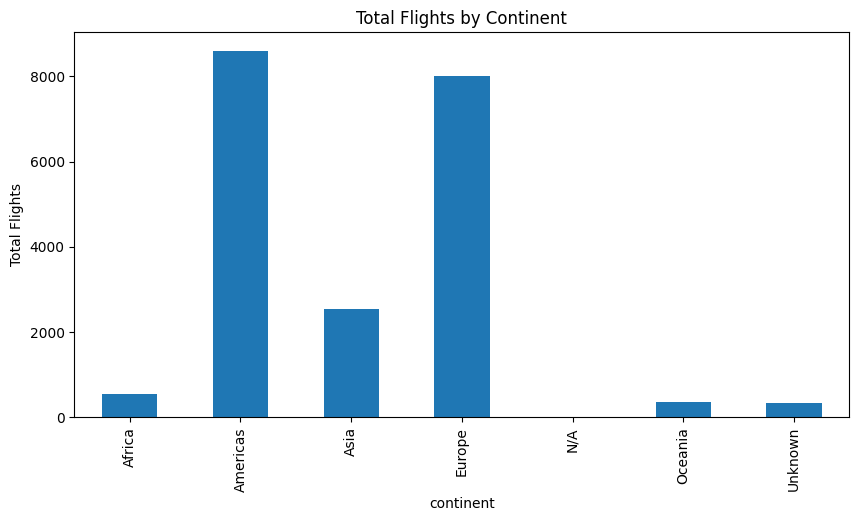

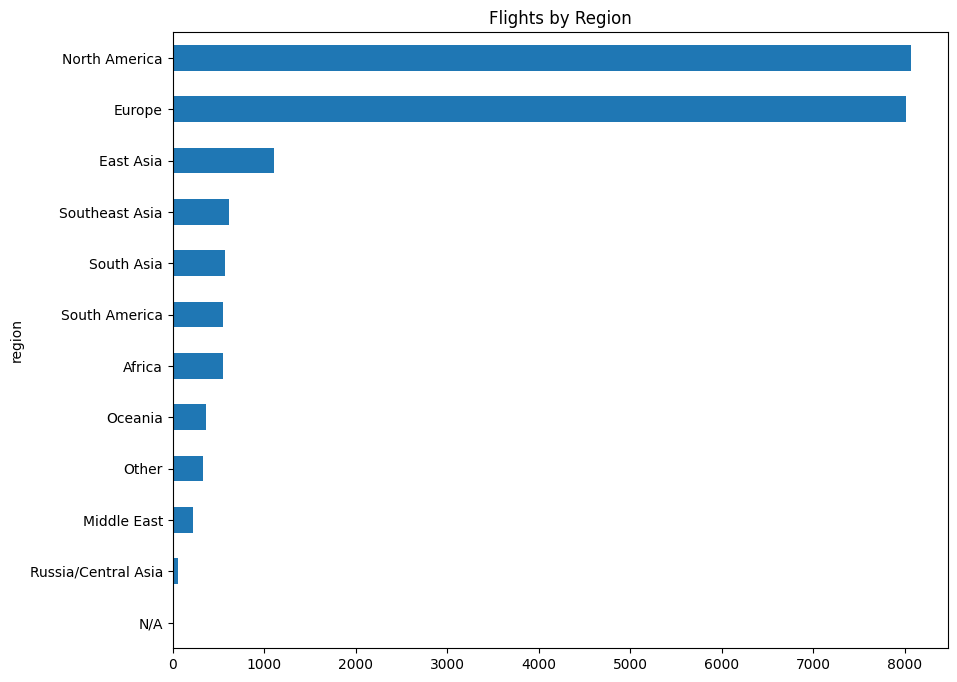

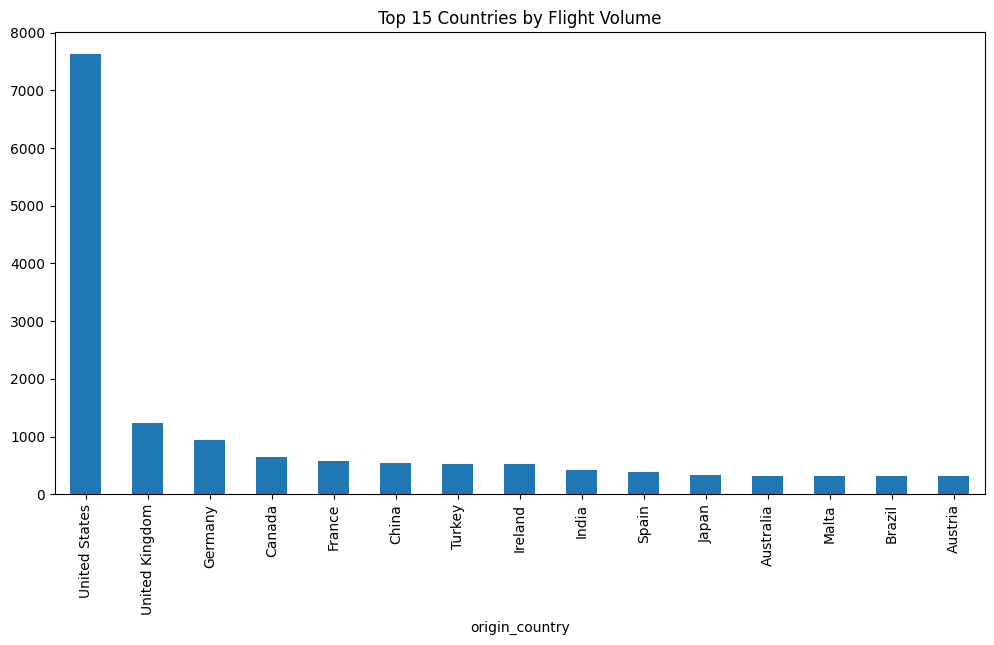

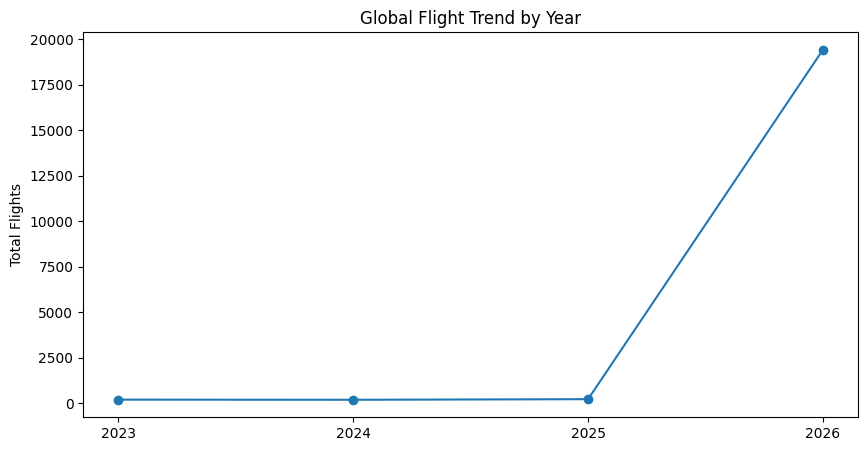

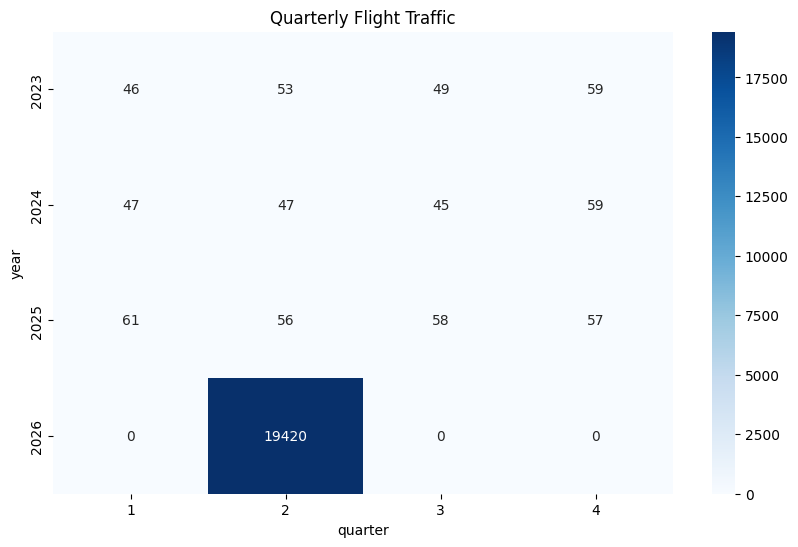

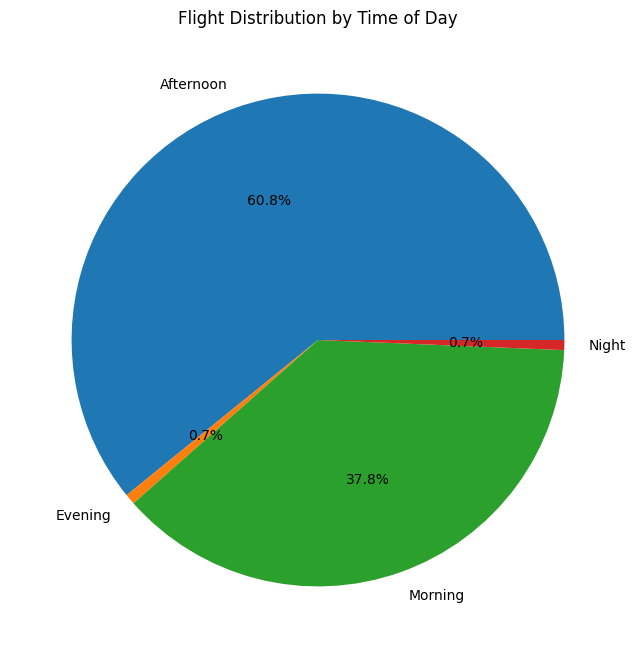

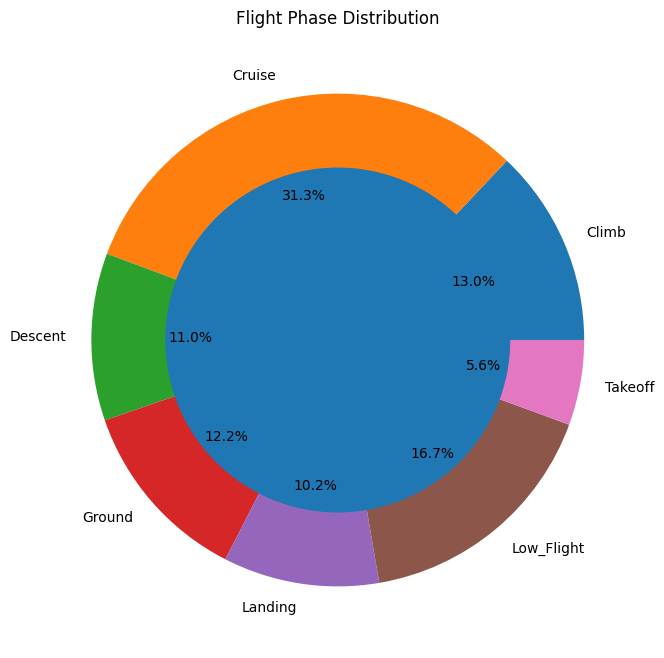

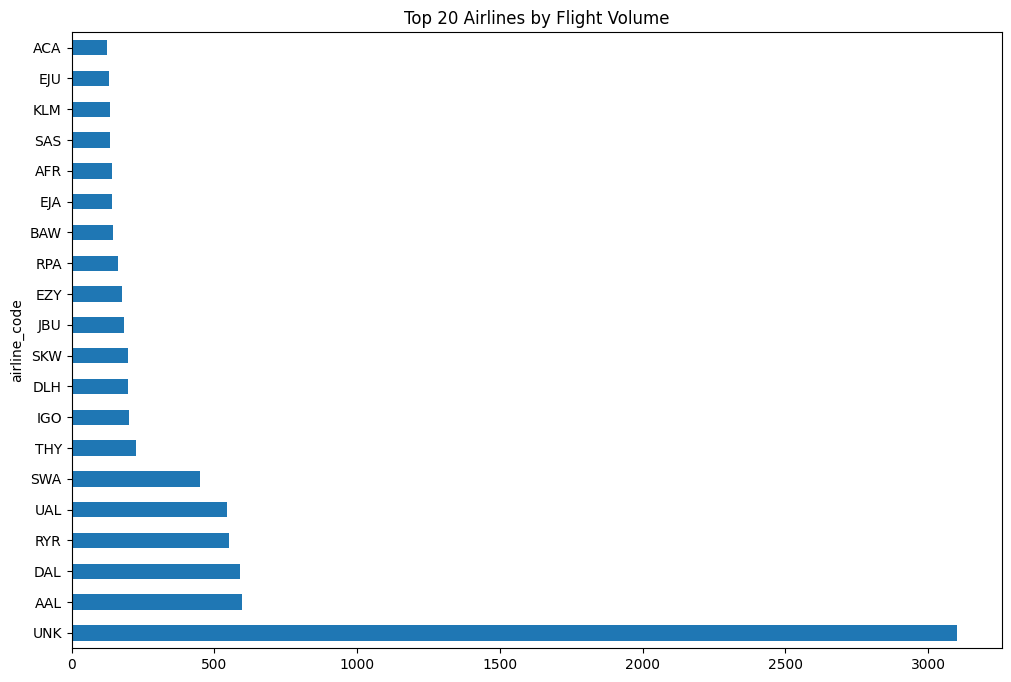

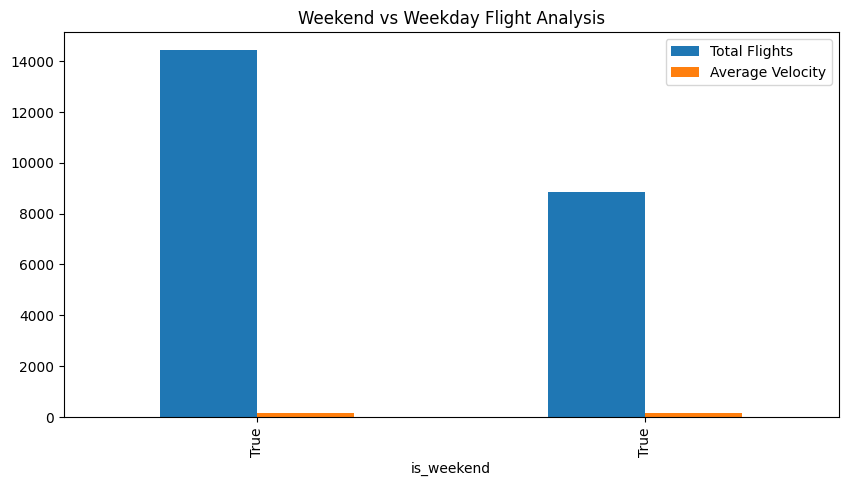

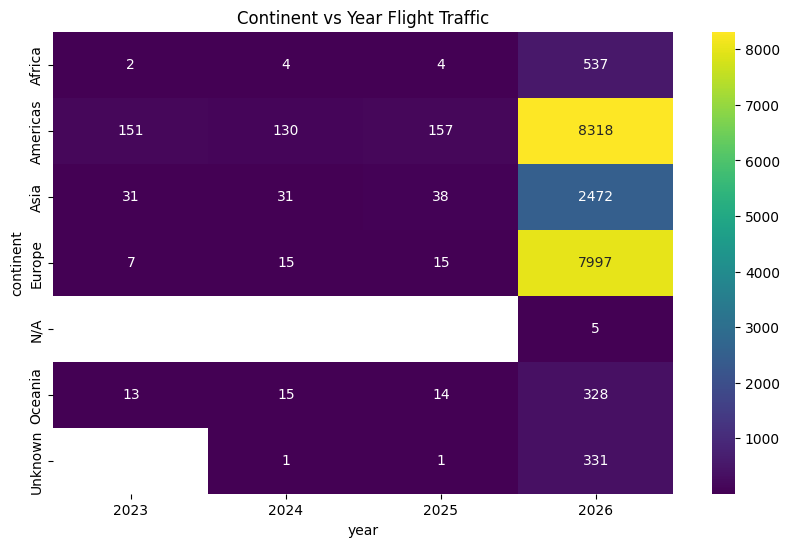

In [102]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(10,5))

result_continent["Total Flights"].plot(kind="bar")

plt.title("Total Flights by Continent")
plt.ylabel("Total Flights")
plt.show()

plt.figure(figsize=(10,8))

result_region.sort_values(
    by="Total Flights",
    ascending=True
)["Total Flights"].plot(kind="barh")

plt.title("Flights by Region")
plt.show()

top_country = result_country.sort_values(
    by="Total Flights",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

top_country["Total Flights"].plot(kind="bar")

plt.title("Top 15 Countries by Flight Volume")
plt.show()

plt.figure(figsize=(10,5))

plt.plot(
    result_year.index.astype(str),
    result_year["Total Flights"],
    marker='o'
)

plt.title("Global Flight Trend by Year")
plt.ylabel("Total Flights")
plt.show()

quarter_heatmap = result_quarter.reset_index()

quarter_heatmap = quarter_heatmap.pivot_table(
    values="Total Flights",
    index="year",
    columns="quarter",
    aggfunc='sum'
)

quarter_heatmap = quarter_heatmap.astype(float)

quarter_heatmap = quarter_heatmap.fillna(0)

plt.figure(figsize=(10,6))

sns.heatmap(
    quarter_heatmap,
    annot=True,
    cmap='Blues',
    fmt='.0f'
)

plt.title("Quarterly Flight Traffic")
plt.show()

plt.figure(figsize=(8,8))

result_timeofday["Total Flights"].plot(
    kind="pie",
    autopct='%1.1f%%'
)

plt.title("Flight Distribution by Time of Day")
plt.ylabel("")
plt.show()

fig, ax = plt.subplots(figsize=(8,8))

ax.pie(
    result_phase["Total Flights"],
    labels=result_phase.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70)

fig.gca().add_artist(centre_circle)

plt.title("Flight Phase Distribution")
plt.show()

top_airline = result_airline.sort_values(
    by="Total Flights",
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

top_airline["Total Flights"].plot(
    kind="barh"
)

plt.title("Top 20 Airlines by Flight Volume")
plt.show()

result_weekend[
    ["Total Flights","Average Velocity"]
].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Weekend vs Weekday Flight Analysis")
plt.show()

continent_year = result_continent_year.reset_index()

continent_year = continent_year.pivot_table(
    values="Total Flights",
    index="continent",
    columns="year"
)

# convert dari pandas Int64 ke numpy float
continent_year = continent_year.astype(float)

plt.figure(figsize=(10,6))

sns.heatmap(
    continent_year,
    annot=True,
    cmap="viridis",
    fmt=".0f"
)

plt.title("Continent vs Year Flight Traffic")
plt.show()

# VISUALISASI DRILL DOWN

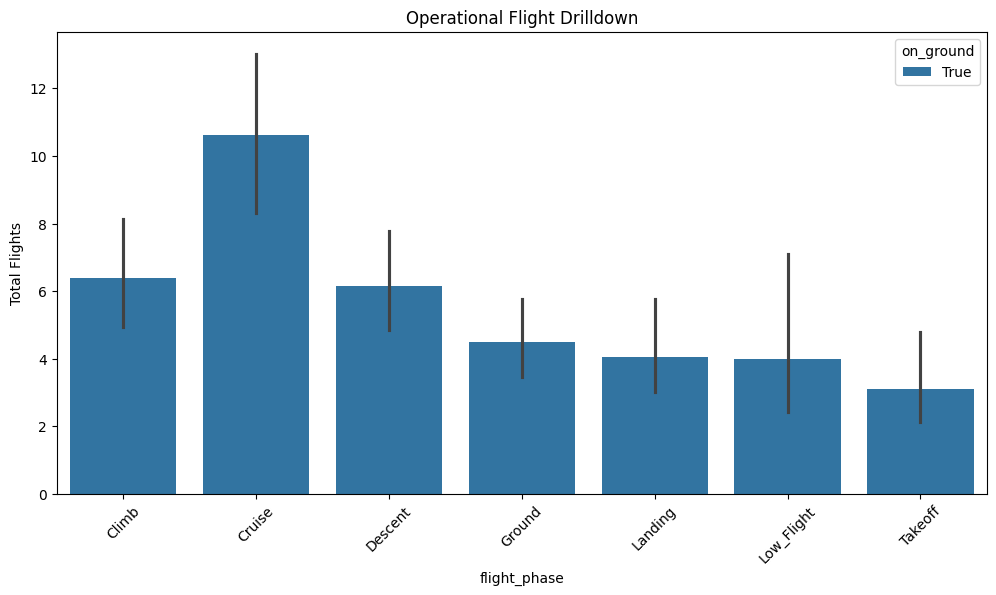

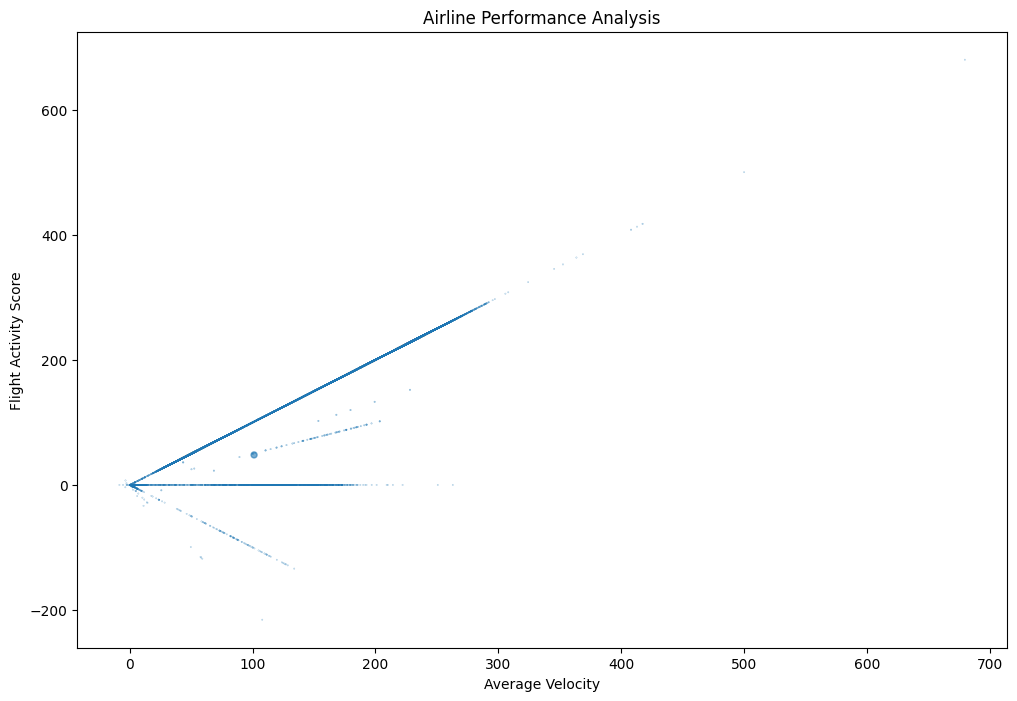

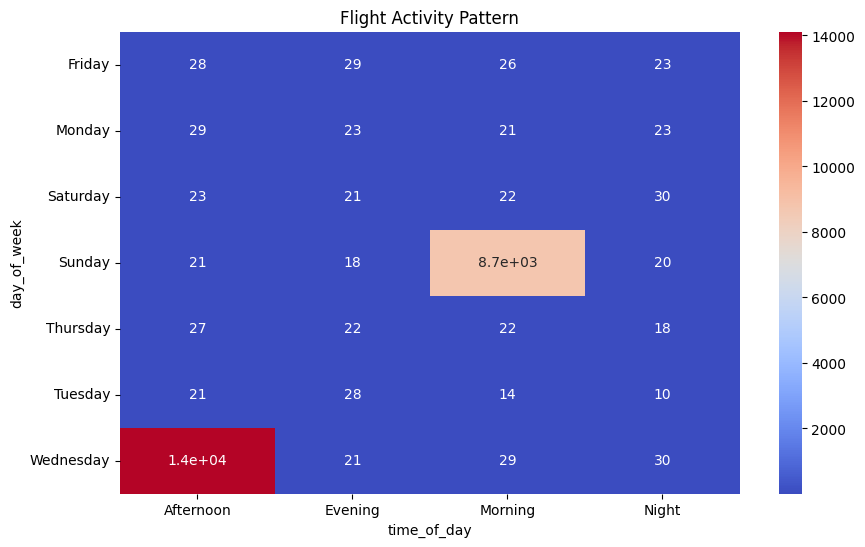

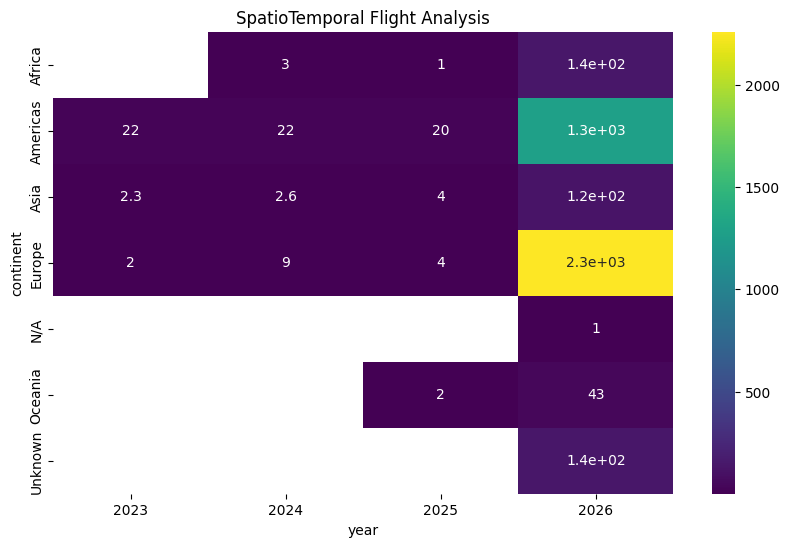

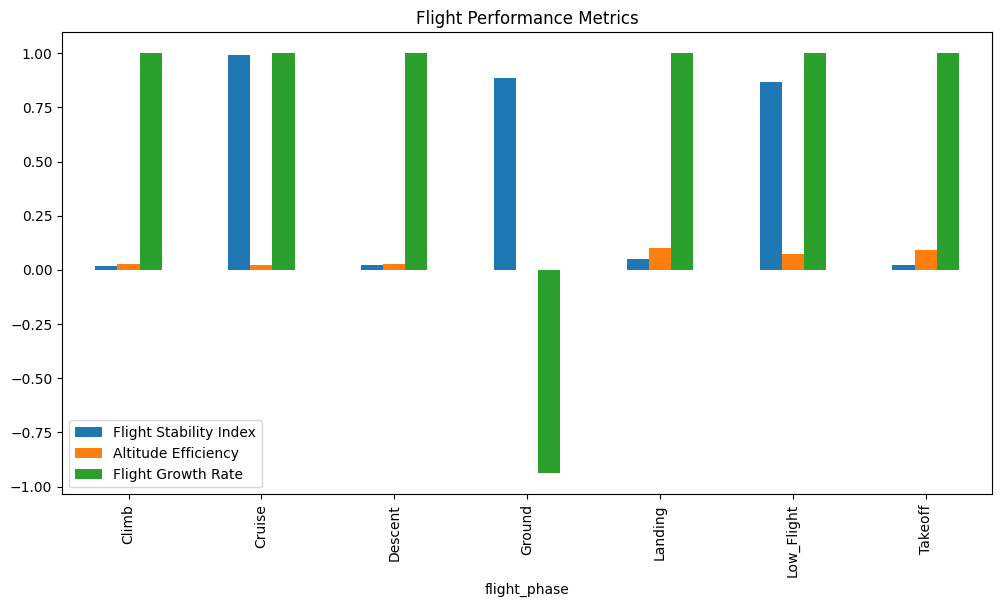

In [103]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default='browser'

fig = px.treemap(
    result_time_drill.reset_index(),
    path=['year','quarter','month_name','day','hour'],
    values='Total Flights',
    color='Average Velocity',
    title='Time Drilldown Flight Analysis'
)

fig.show()

fig = px.sunburst(
    result_geo_drill.reset_index(),
    path=[
        'continent',
        'region',
        'origin_country'
    ],
    values='Total Flights',
    color='Flight Activity Score',
    title='Geographic Drilldown Analysis'
)

fig.show()

flight = result_flight_drill.reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=flight,
    x='flight_phase',
    y='Total Flights',
    hue='on_ground'
)

plt.xticks(rotation=45)

plt.title("Operational Flight Drilldown")

plt.show()

airline = result_airline_drill.reset_index()

plt.figure(figsize=(12,8))

plt.scatter(
    airline['Average Velocity'],
    airline['Flight Activity Score'],
    s=airline['Total Flights']/20,
    alpha=0.6
)

plt.xlabel("Average Velocity")
plt.ylabel("Flight Activity Score")
plt.title("Airline Performance Analysis")

plt.show()

activity = result_activity_drill.reset_index()

activity_heatmap = activity.pivot_table(
    values='Total Flights',
    index='day_of_week',
    columns='time_of_day'
)

activity_heatmap = activity_heatmap.astype(float)

plt.figure(figsize=(10,6))

sns.heatmap(
    activity_heatmap,
    annot=True,
    cmap='coolwarm'
)

plt.title("Flight Activity Pattern")

plt.show()

spatio = result_spatiotemporal.reset_index()

spatio_map = spatio.pivot_table(
    values='Total Flights',
    index='continent',
    columns='year'
)

spatio_map = spatio_map.astype(float)

plt.figure(figsize=(10,6))

sns.heatmap(
    spatio_map,
    annot=True,
    cmap='viridis'
)

plt.title("SpatioTemporal Flight Analysis")

plt.show()

performance = result_performance.reset_index()

top_perf = performance.groupby(
    'flight_phase'
)[[
    'Flight Stability Index',
    'Altitude Efficiency',
    'Flight Growth Rate'
]].mean()

top_perf.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Flight Performance Metrics")

plt.show()



# VISUALISASI SLICE

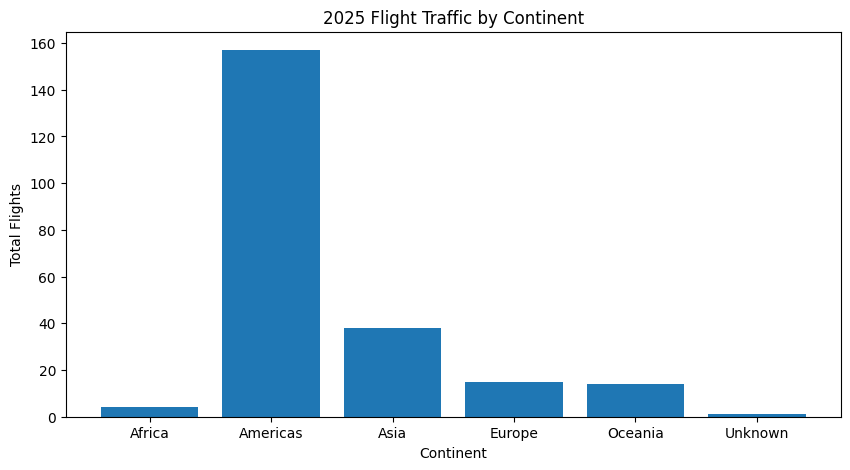

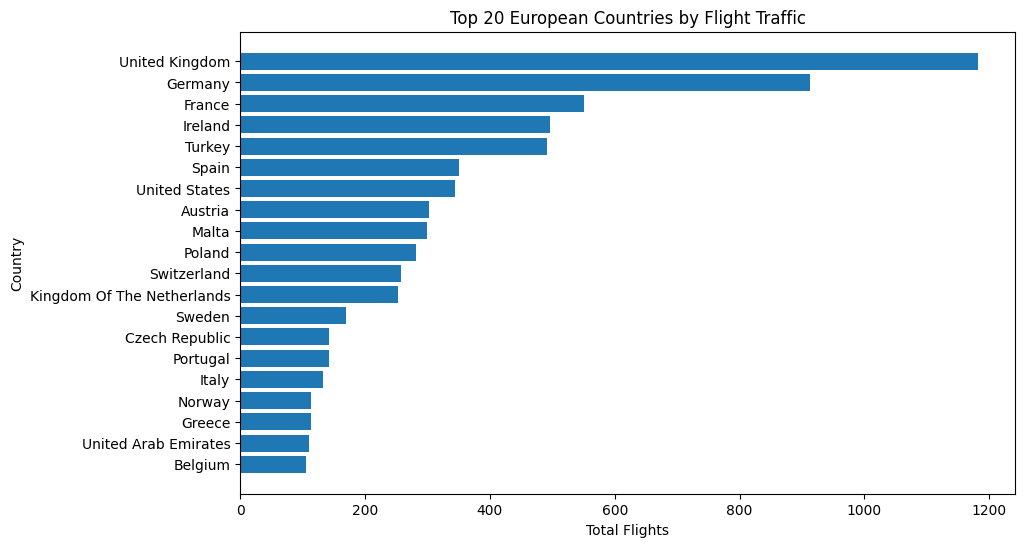

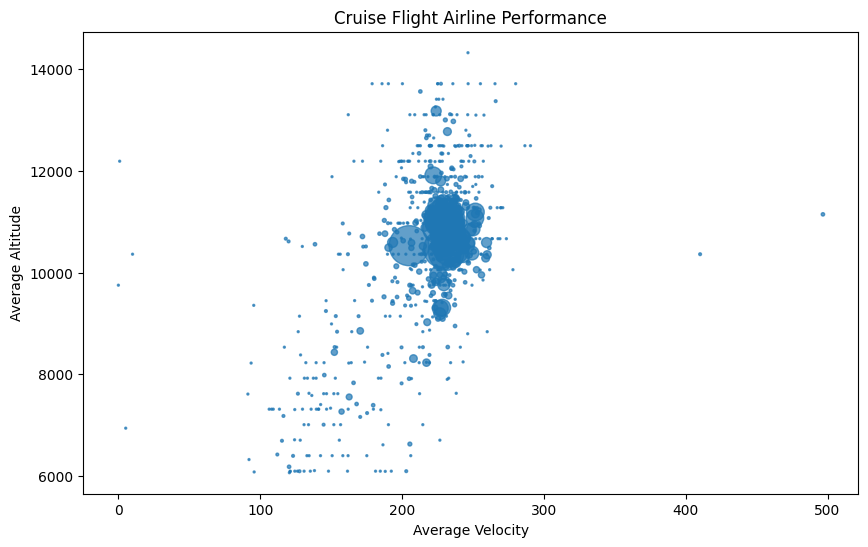

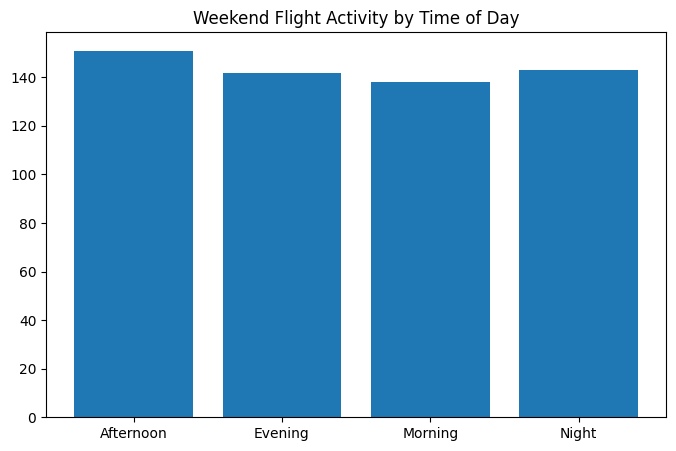

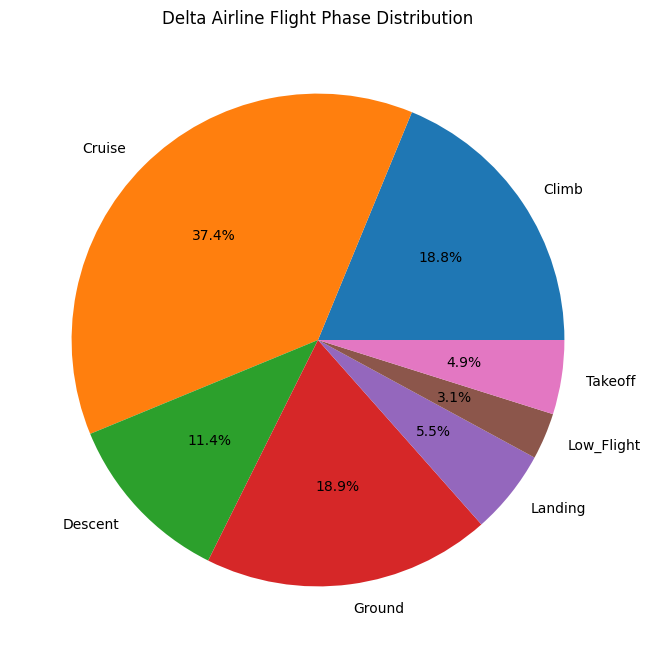

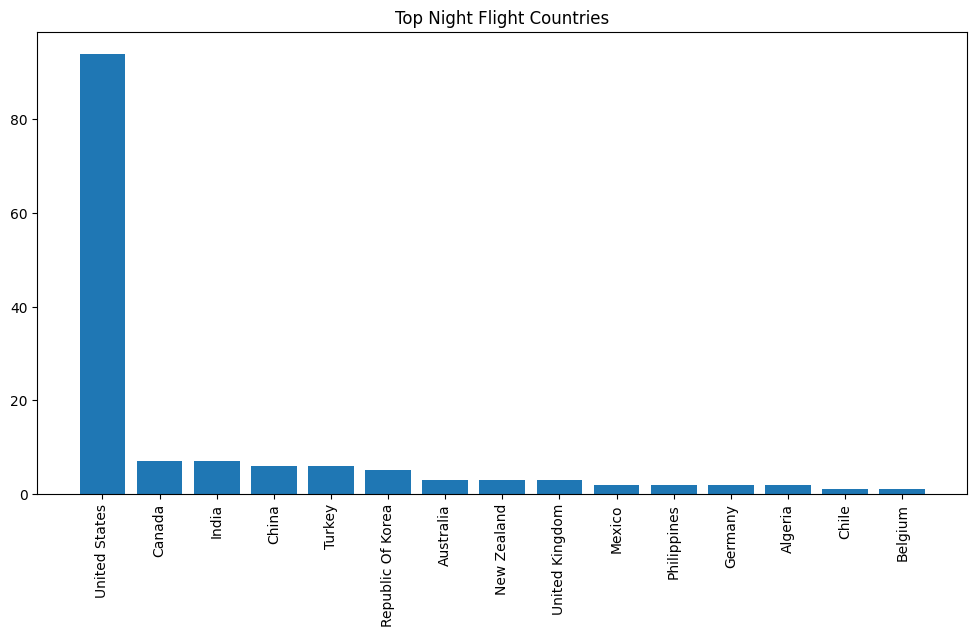

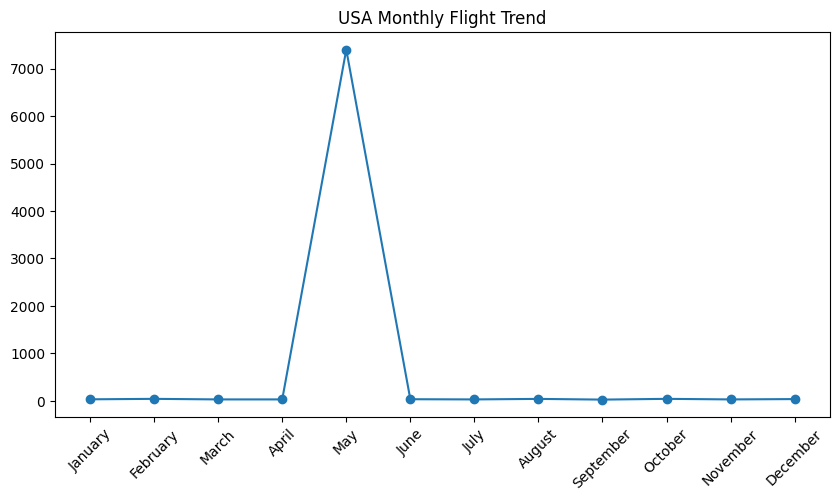

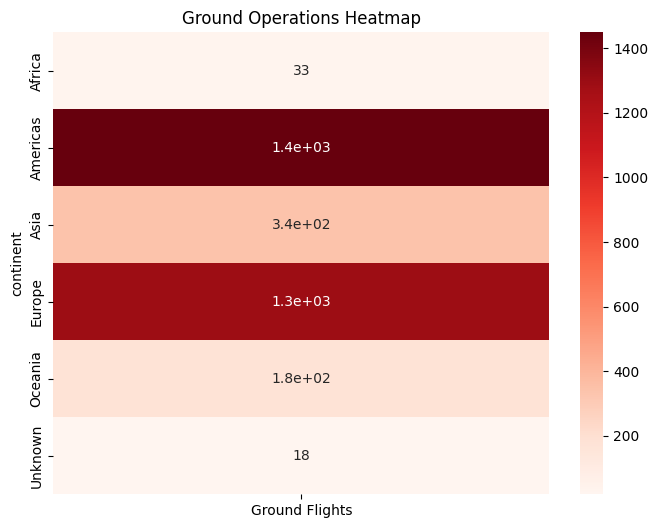

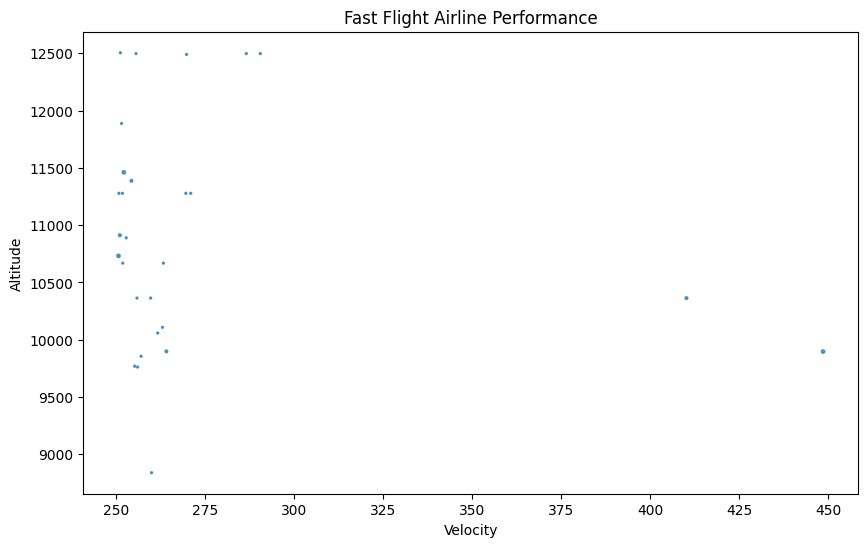

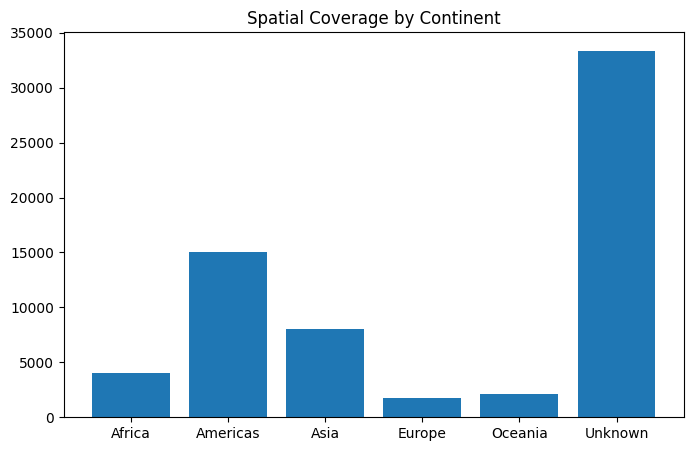

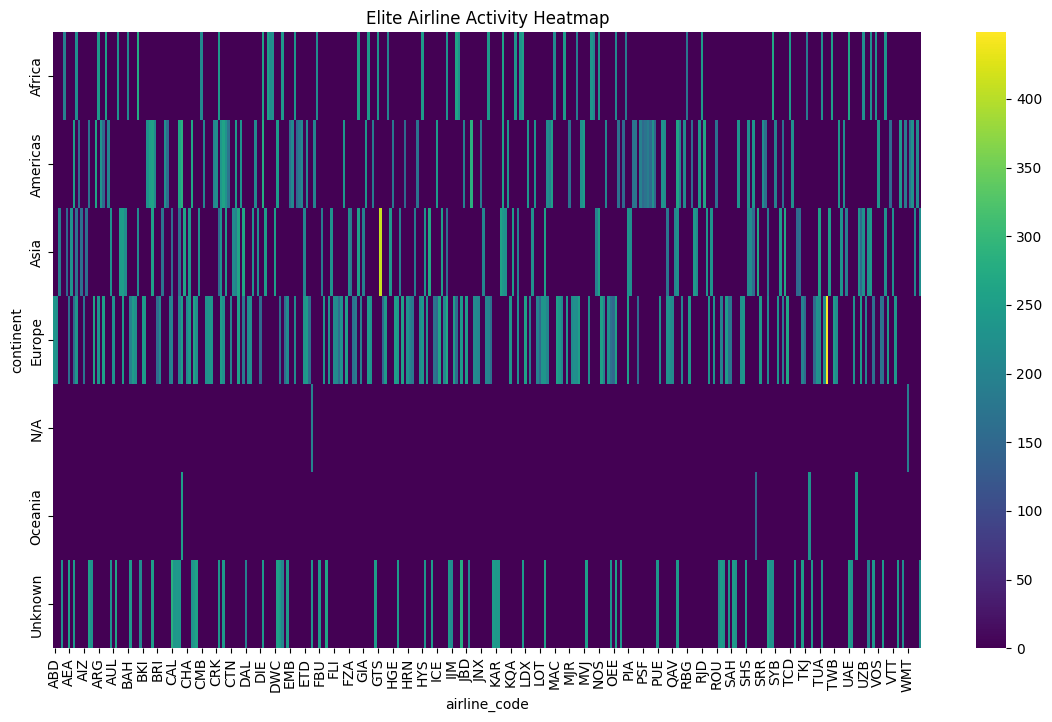

In [104]:
year2025 = result_slice_year.reset_index()

plt.figure(figsize=(10,5))

plt.bar(
    year2025["continent"],
    year2025["Total Flights"]
)

plt.title("2025 Flight Traffic by Continent")
plt.xlabel("Continent")
plt.ylabel("Total Flights")

plt.show()

europe = result_slice_europe.reset_index()

# rename kalau muncul "index"
europe = europe.rename(
    columns={"index":"origin_country"}
)

# ambil TOP 10
europe = europe.sort_values(
    by="Total Flights",
    ascending=False
).head(20)

plt.figure(figsize=(10,6))

plt.barh(
    europe["origin_country"],
    europe["Total Flights"]
)

plt.xlabel("Total Flights")
plt.ylabel("Country")
plt.title("Top 20 European Countries by Flight Traffic")

plt.gca().invert_yaxis()

plt.show()
cruise = result_slice_cruise.reset_index()

plt.figure(figsize=(10,6))

plt.scatter(
    cruise["Average Velocity"],
    cruise["Average Altitude"],
    s=cruise["Total Flights"]*2,
    alpha=0.7
)

plt.xlabel("Average Velocity")
plt.ylabel("Average Altitude")
plt.title("Cruise Flight Airline Performance")

plt.show()

weekend = result_slice_weekend.reset_index()

plt.figure(figsize=(8,5))

plt.bar(
    weekend["time_of_day"],
    weekend["Flight Activity Score"]
)

plt.title("Weekend Flight Activity by Time of Day")

plt.show()

dal = result_slice_airline.reset_index()

plt.figure(figsize=(8,8))

plt.pie(
    dal["Total Flights"],
    labels=dal["flight_phase"],
    autopct='%1.1f%%'
)

plt.title("Delta Airline Flight Phase Distribution")

plt.show()

night = result_slice_night.reset_index()

night = night.sort_values(
    by="Total Flights",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

plt.bar(
    night["origin_country"],
    night["Total Flights"]
)

plt.xticks(rotation=90)

plt.title("Top Night Flight Countries")

plt.show()

usa = result_slice_usa.reset_index()

month_order = [
'January','February','March','April',
'May','June','July','August',
'September','October','November','December'
]

usa["month_name"] = pd.Categorical(
    usa["month_name"],
    categories=month_order,
    ordered=True
)

usa = usa.sort_values("month_name")

plt.figure(figsize=(10,5))

plt.plot(
    usa["month_name"],
    usa["Total Flights"],
    marker='o'
)

plt.xticks(rotation=45)

plt.title("USA Monthly Flight Trend")

plt.show()

ground = result_slice_ground.reset_index()

ground_matrix = ground.pivot_table(
    values="Ground Flights",
    index="continent"
)

ground_matrix = ground_matrix.astype(float)

plt.figure(figsize=(8,6))

sns.heatmap(
    ground_matrix,
    annot=True,
    cmap="Reds"
)

plt.title("Ground Operations Heatmap")

plt.show()

fast = result_fastflight.reset_index()

plt.figure(figsize=(10,6))

plt.scatter(
    fast["Average Velocity"],
    fast["Average Altitude"],
    s=fast["Total Flights"]*2,
    alpha=0.7
)

plt.xlabel("Velocity")
plt.ylabel("Altitude")

plt.title("Fast Flight Airline Performance")

plt.show()

spatial = result_spatial.reset_index()

plt.figure(figsize=(8,5))

plt.bar(
    spatial["continent"],
    spatial["Spatial Coverage"]
)

plt.title("Spatial Coverage by Continent")

plt.show()

elite = result_elite.reset_index()

elite_map = elite.pivot_table(
    values="Flight Activity Score",
    index="continent",
    columns="airline_code"
)

elite_map = elite_map.fillna(0).astype(float)

plt.figure(figsize=(14,8))

sns.heatmap(
    elite_map,
    cmap="viridis",
    annot=False
)

plt.title("Elite Airline Activity Heatmap")

plt.show()

# VISUALISASI DICE

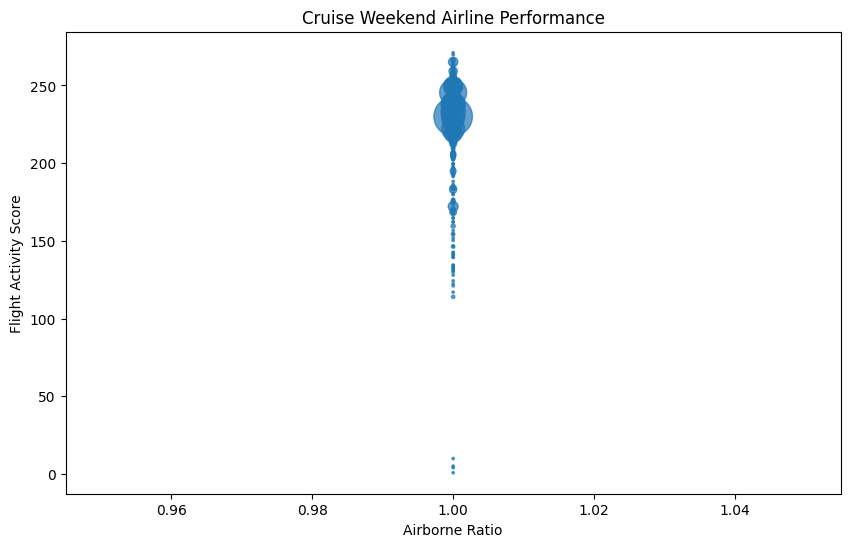

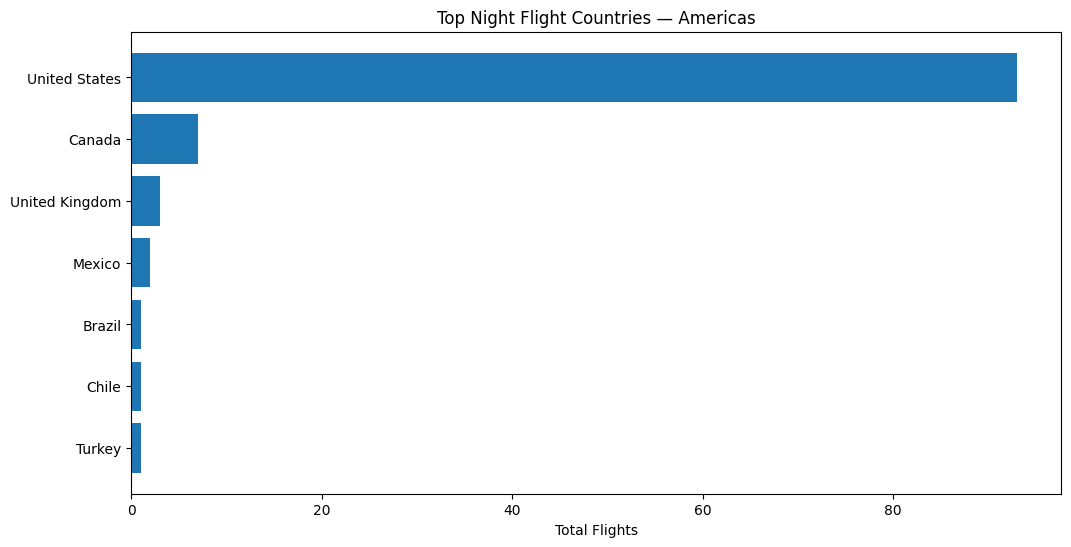

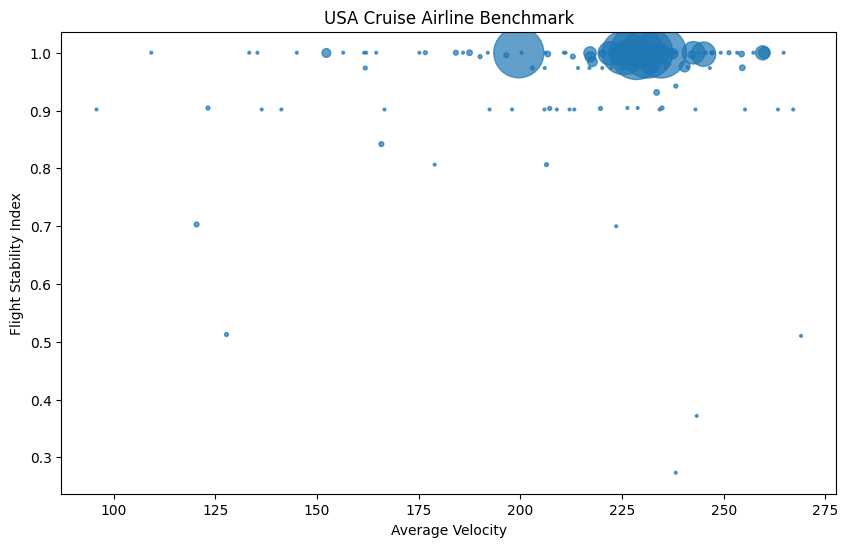

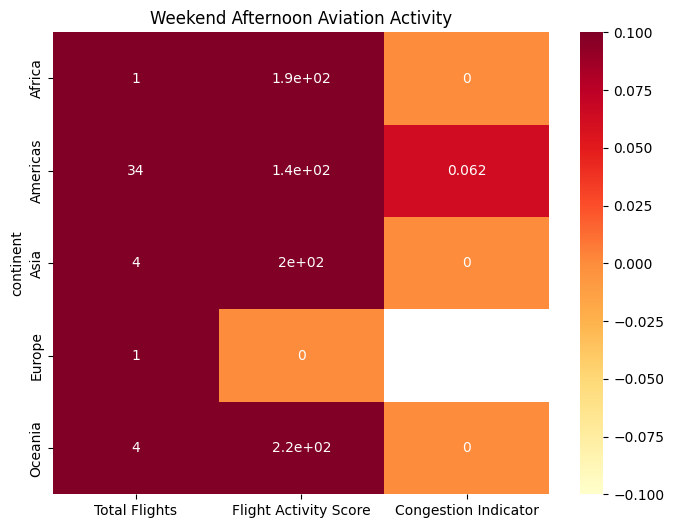

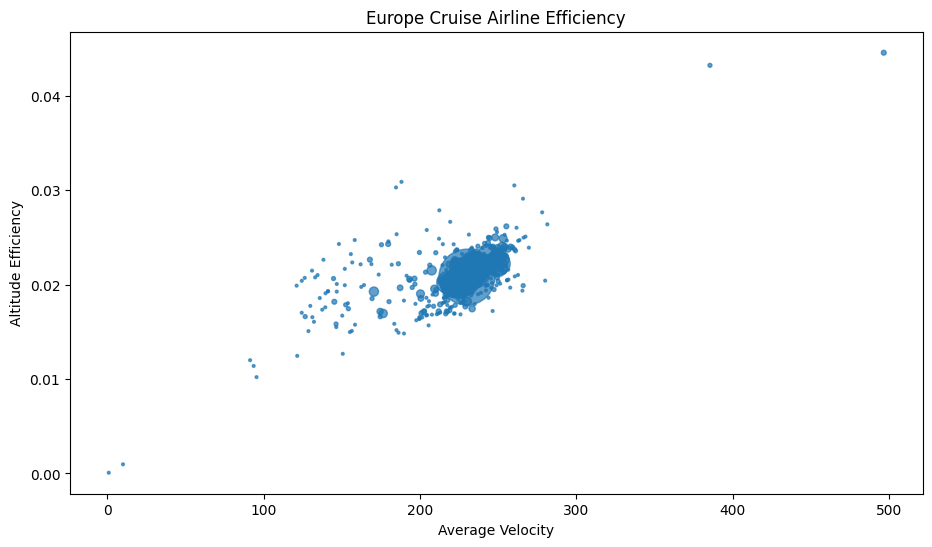

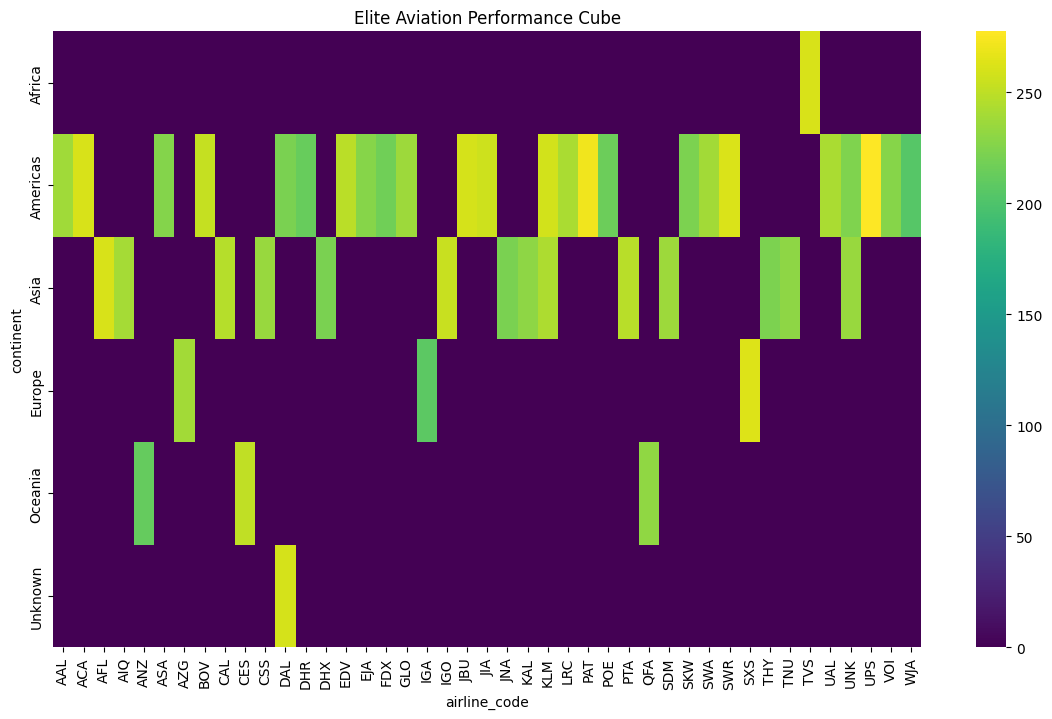

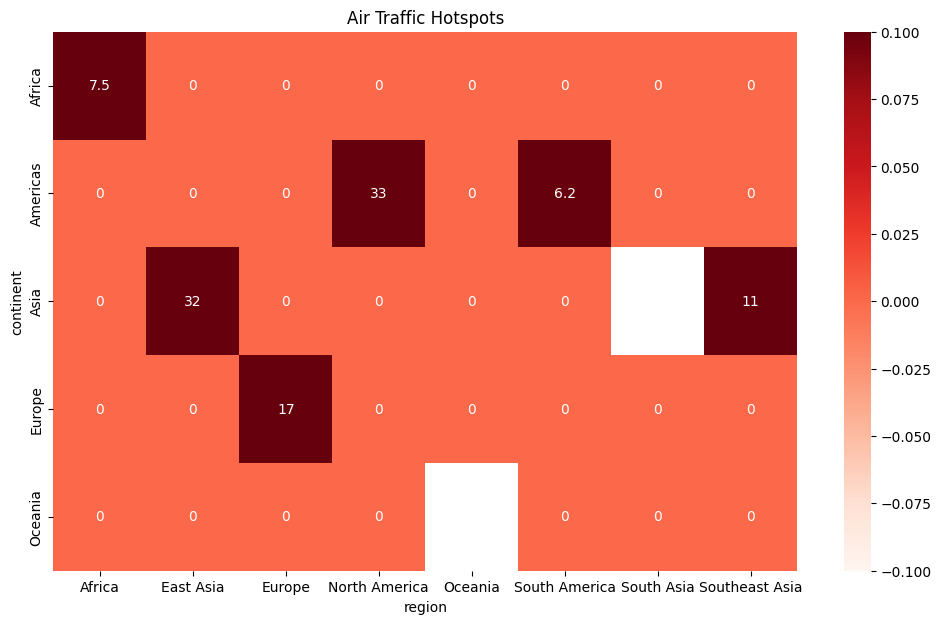

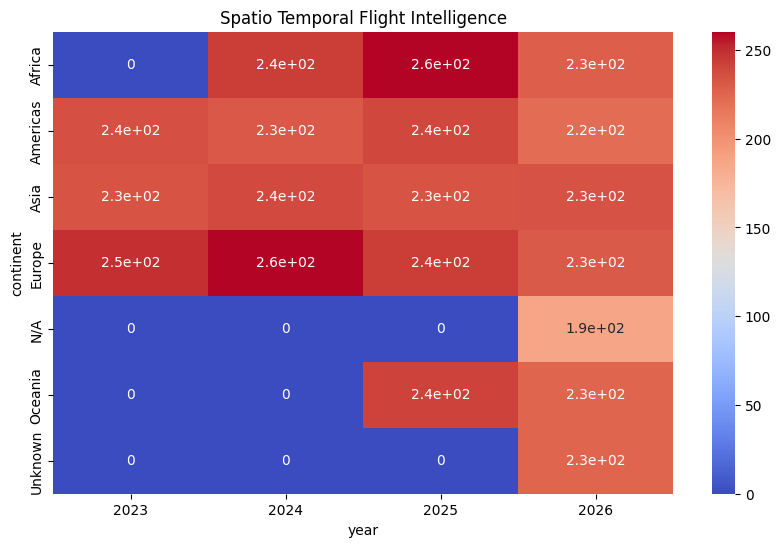

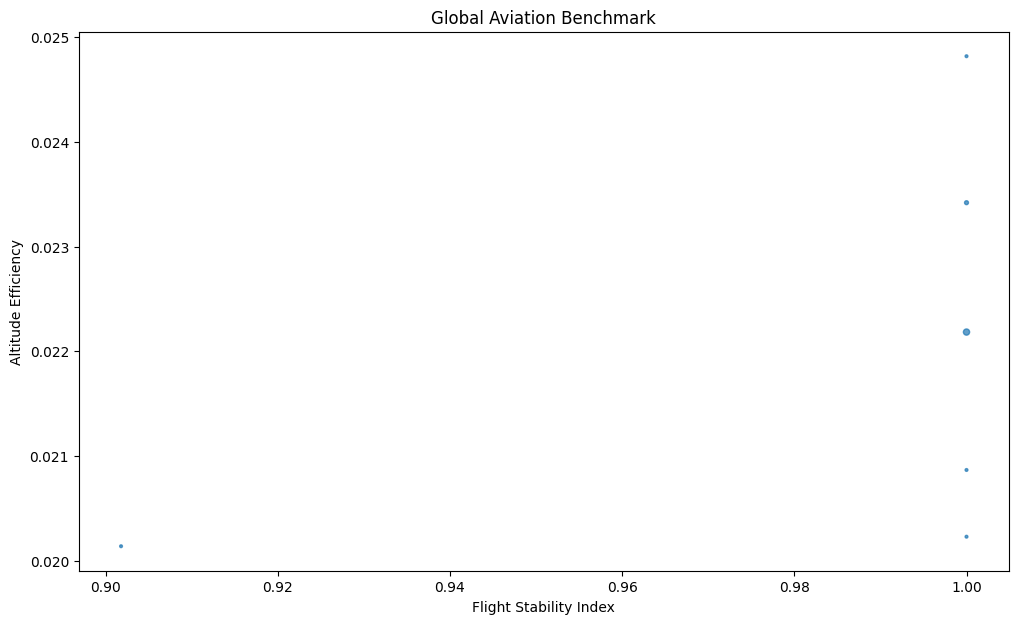

In [105]:
ops = result_dice_ops.reset_index()

ops = ops.rename(
    columns={"index":"airline"}
)

plt.figure(figsize=(10,6))

plt.scatter(
    ops["Airborne Ratio"],
    ops["Flight Activity Score"],
    s=ops["Total Flights"]*3,
    alpha=0.7
)

plt.xlabel("Airborne Ratio")
plt.ylabel("Flight Activity Score")

plt.title("Cruise Weekend Airline Performance")

plt.show()

geo = result_dice_geo_time.reset_index()

geo = geo.sort_values(
    by="Total Flights",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

plt.barh(
    geo["origin_country"],
    geo["Total Flights"]
)

plt.gca().invert_yaxis()

plt.title("Top Night Flight Countries — Americas")
plt.xlabel("Total Flights")
plt.show()

usa = result_dice_country_airline.reset_index()

usa = usa.rename(
    columns={"index":"airline"}
)

plt.figure(figsize=(10,6))

plt.scatter(
    usa["Average Velocity"],
    usa["Flight Stability Index"],
    s=usa["Total Flights"]*4,
    alpha=0.7
)

plt.xlabel("Average Velocity")
plt.ylabel("Flight Stability Index")

plt.title("USA Cruise Airline Benchmark")

plt.show()

activity = result_dice_activity.reset_index()

activity = activity.rename(
    columns={"index":"continent"}
)

heat = activity.set_index(
    "continent"
)[["Total Flights","Flight Activity Score","Congestion Indicator"]]

heat = heat.astype(float)

plt.figure(figsize=(8,6))

sns.heatmap(
    heat,
    annot=True,
    cmap="YlOrRd"
)

plt.title("Weekend Afternoon Aviation Activity")

plt.show()

geoair = result_dice_airline_geo.reset_index()

geoair = geoair.rename(
    columns={"index":"airline"}
)

plt.figure(figsize=(11,6))

plt.scatter(
    geoair["Average Velocity"],
    geoair["Altitude Efficiency"],
    s=geoair["Total Flights"]*4,
    alpha=0.7
)

plt.xlabel("Average Velocity")
plt.ylabel("Altitude Efficiency")

plt.title("Europe Cruise Airline Efficiency")

plt.show()

elite = result_elite_cube.reset_index()

elite = elite.rename(
    columns={
        "index":"continent"
    }
)

elite_map = elite.pivot_table(
    values="Flight Activity Score",
    index="continent",
    columns="airline_code"
)

elite_map = elite_map.fillna(0).astype(float)

plt.figure(figsize=(14,8))

sns.heatmap(
    elite_map,
    cmap="viridis"
)

plt.title("Elite Aviation Performance Cube")

plt.show()

hotspot = result_hotspot.reset_index()

hotspot.columns = [
'continent',
'region',
'Total Flights',
'Regional Traffic Share',
'Congestion Indicator'
]

pivot_hotspot = hotspot.pivot_table(
    values="Congestion Indicator",
    index="continent",
    columns="region"
)

pivot_hotspot = pivot_hotspot.fillna(0).astype(float)

plt.figure(figsize=(12,7))

sns.heatmap(
    pivot_hotspot,
    annot=True,
    cmap="Reds"
)

plt.title("Air Traffic Hotspots")

plt.show()

spatio = result_spatiotemporal.reset_index()

spatio.columns = [
'year',
'continent',
'region',
'Total Flights',
'Average Velocity',
'Flight Activity Score',
'Spatial Coverage'
]

heat = spatio.pivot_table(
    values="Flight Activity Score",
    index="continent",
    columns="year"
)

heat = heat.fillna(0).astype(float)

plt.figure(figsize=(10,6))

sns.heatmap(
    heat,
    annot=True,
    cmap="coolwarm"
)

plt.title("Spatio Temporal Flight Intelligence")

plt.show()

bench = result_benchmark.reset_index()

bench.columns = [
'continent',
'country',
'Total Flights',
'Flight Stability Index',
'Altitude Efficiency',
'Active Airline Ratio',
'Flight Growth Rate'
]

plt.figure(figsize=(12,7))

plt.scatter(
    bench["Flight Stability Index"],
    bench["Altitude Efficiency"],
    s=bench["Total Flights"]*4,
    alpha=0.7
)

plt.xlabel("Flight Stability Index")
plt.ylabel("Altitude Efficiency")

plt.title("Global Aviation Benchmark")

plt.show()




# VISUALISASI TAMBAHAN

Total Flights : 20049
Average Altitude : 5949.46


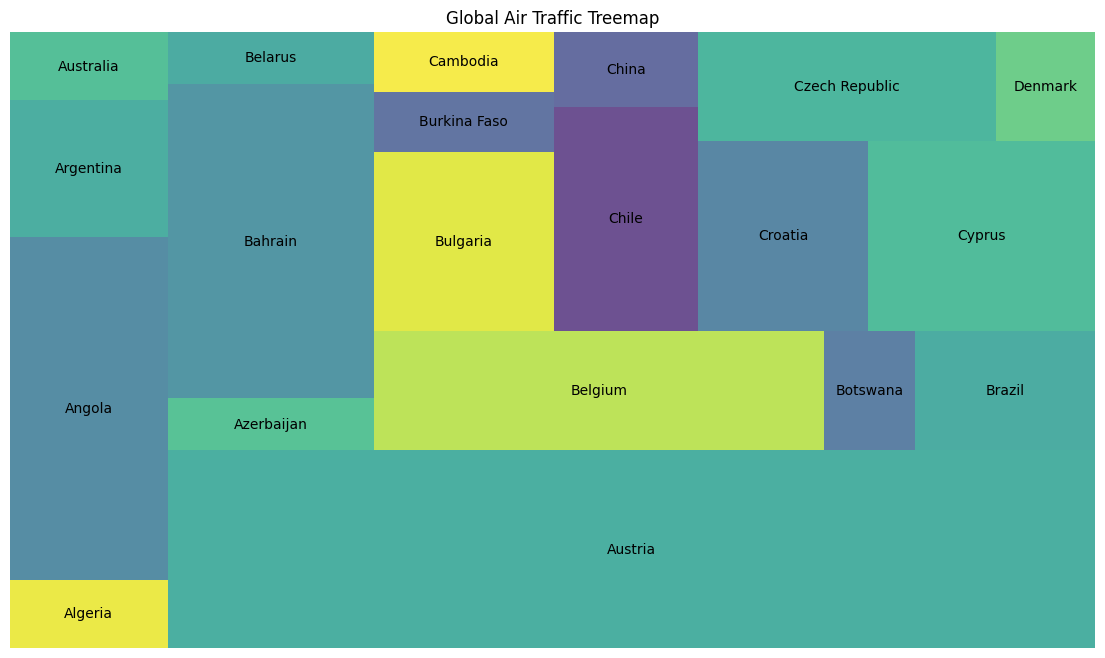

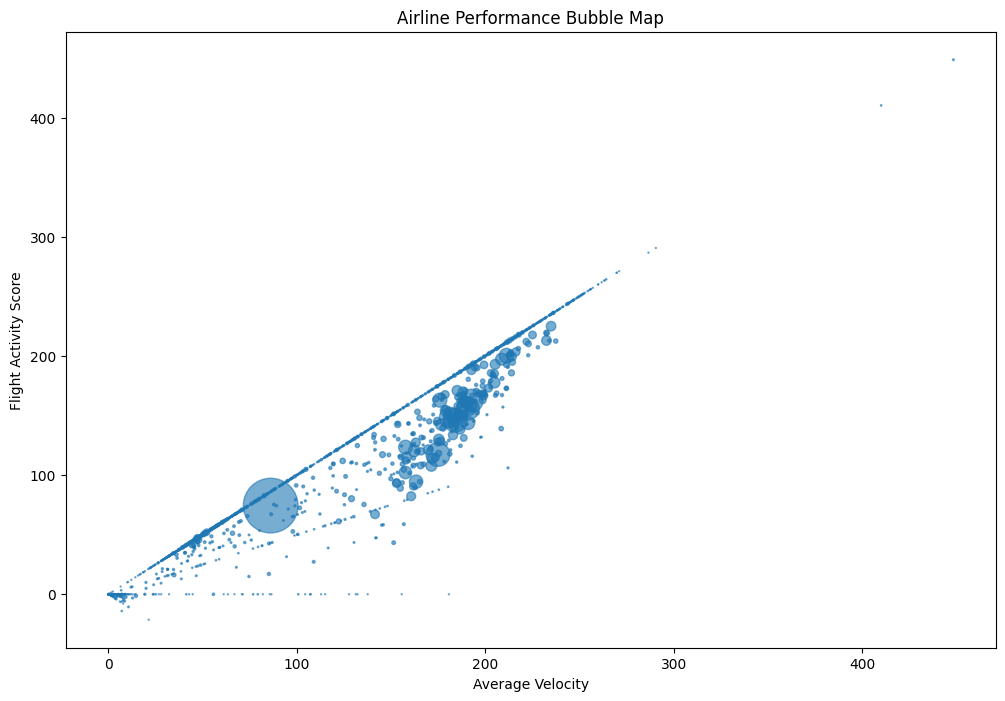

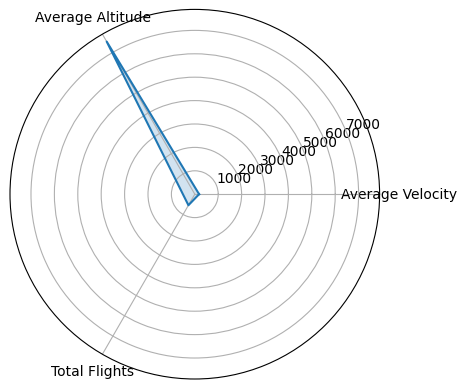

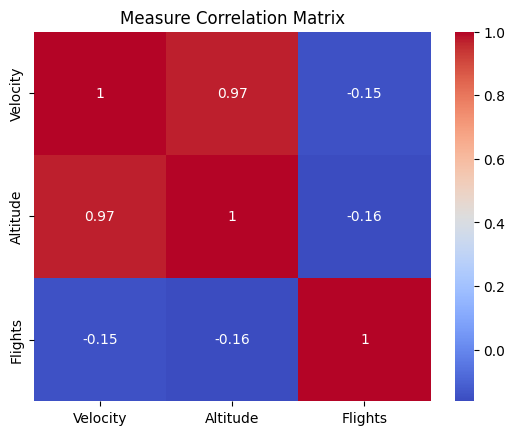

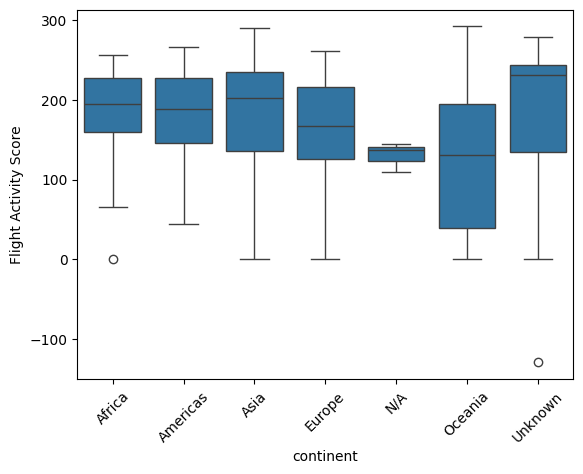

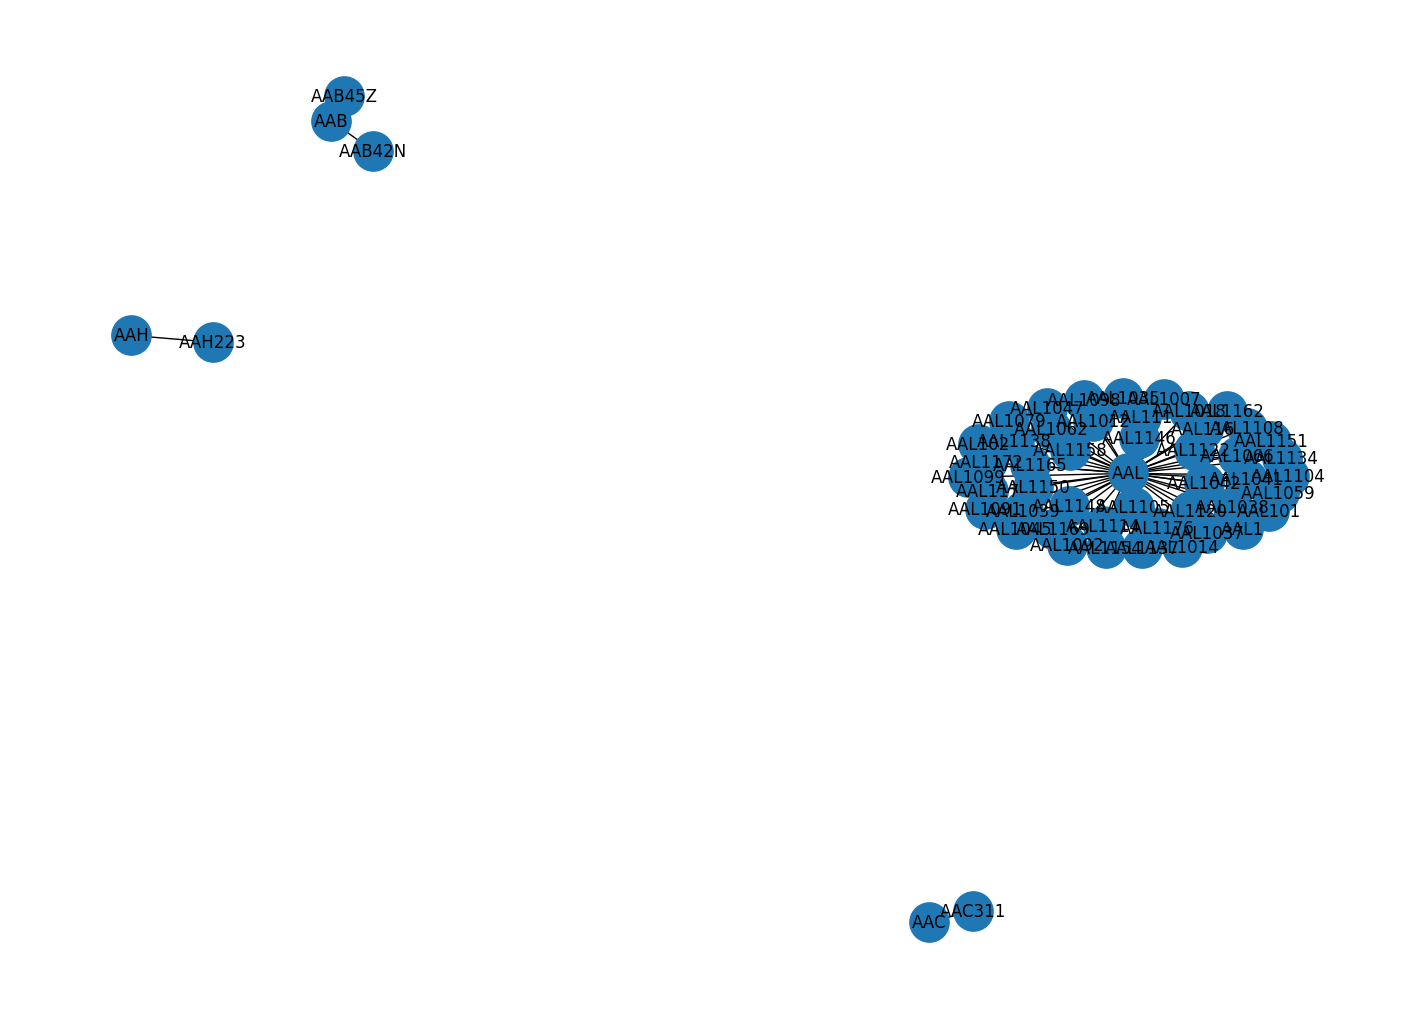

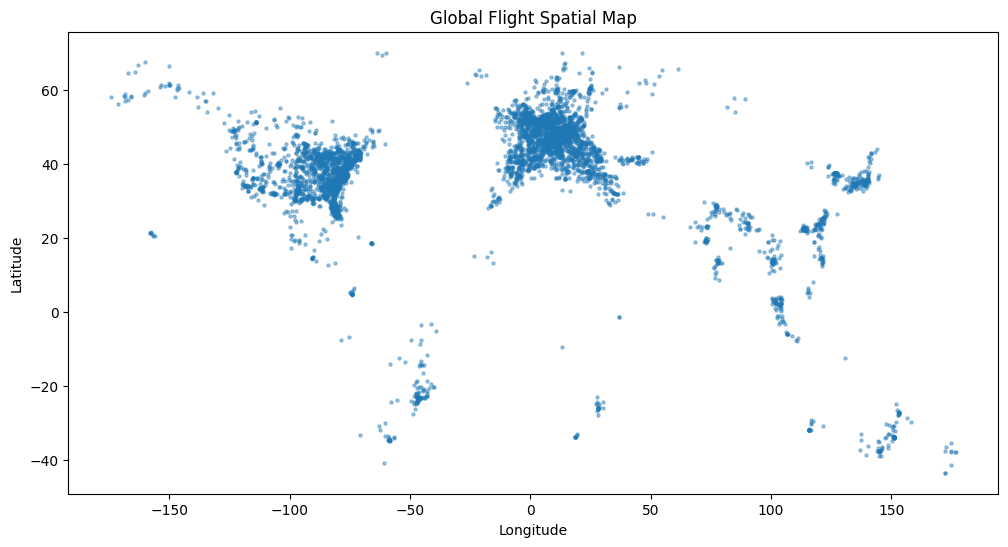

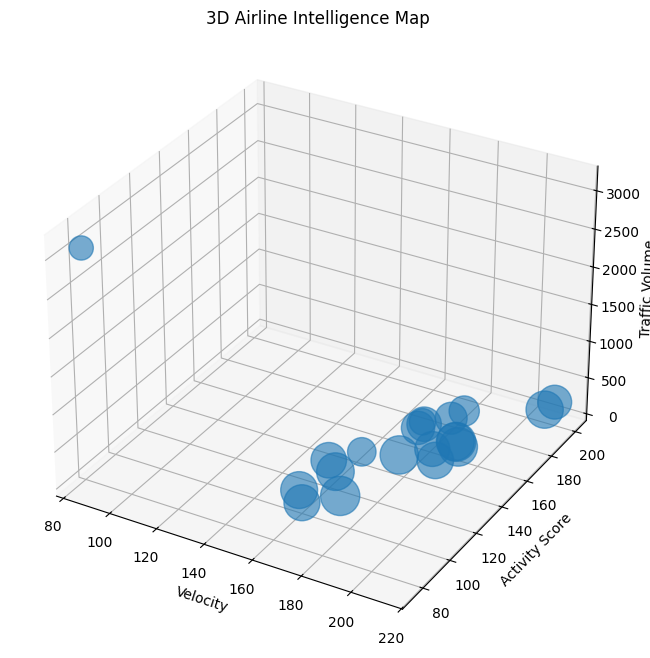

In [106]:
print("Total Flights :", result_year["Total Flights"].sum())
print("Average Altitude :", round(result_year["Average Altitude"].mean(),2))

import squarify

geo = result_geo.reset_index()

sizes = geo["Total Flights"].head(20)

labels = geo["origin_country"].head(20)

plt.figure(figsize=(14,8))

squarify.plot(
    sizes=sizes,
    label=labels,
    alpha=0.8
)

plt.axis('off')
plt.title("Global Air Traffic Treemap")
plt.show()

air = result_airline.reset_index()

plt.figure(figsize=(12,8))

plt.scatter(
    air["Average Velocity"],
    air["Flight Activity Score"],
    s=air["Total Flights"]/2,
    alpha=0.6
)

plt.xlabel("Average Velocity")
plt.ylabel("Flight Activity Score")

plt.title("Airline Performance Bubble Map")

plt.show()

from math import pi

radar = result_continent.reset_index()

categories = [
'Average Velocity',
'Average Altitude',
'Total Flights'
]

values = radar.iloc[0][categories].tolist()

values += values[:1]

angles = [n/float(len(categories))*2*pi for n in range(len(categories))]
angles += angles[:1]

ax = plt.subplot(111, polar=True)

plt.xticks(angles[:-1], categories)

ax.plot(angles, values)

plt.fill(angles, values, alpha=0.2)

plt.show()

corr_data = pd.DataFrame({

'Velocity':result_continent["Average Velocity"],

'Altitude':result_continent["Average Altitude"],

'Flights':result_continent["Total Flights"]

})

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Measure Correlation Matrix")
plt.show()

air = result_airline.reset_index()

air = air.sort_values(
    by='Total Flights',
    ascending=False
).head(20)

air['cumperc'] = (
    air['Total Flights'].cumsum()
    /air['Total Flights'].sum()
)*100

geo = result_geo_drill.reset_index()

sns.boxplot(
    x="continent",
    y="Flight Activity Score",
    data=geo
)

plt.xticks(rotation=45)

plt.show()

import networkx as nx

G = nx.Graph()

sample = result_airline_drill.reset_index().head(50)

for _,row in sample.iterrows():

    G.add_edge(
        row['airline_code'],
        row['callsign']
    )

plt.figure(figsize=(14,10))

nx.draw(
    G,
    with_labels=True,
    node_size=800
)

plt.show()

spatial = df.sample(5000)

plt.figure(figsize=(12,6))

plt.scatter(

spatial['longitude'],

spatial['latitude'],

alpha=0.4,

s=5

)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Global Flight Spatial Map")

plt.show()

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(

    air["Average Velocity"],

    air["Flight Activity Score"],

    air["Total Flights"],

    s=air["cumperc"]*8,

    alpha=0.6
)

ax.set_xlabel("Velocity")
ax.set_ylabel("Activity Score")
ax.set_zlabel("Traffic Volume")

plt.title("3D Airline Intelligence Map")

plt.show()

# PERBANDINGAN BENCHMARK TIAP LEVEL KOMPLEKSITAS OLAP

In [107]:
import time
benchmark_results = []

# SIMPLE QUERY
start = time.perf_counter()

simple_query = cube.query(
    m["Total Flights"],
    levels=[
        l[("opensky_flight","continent","continent")]
    ]
)

end = time.perf_counter()

benchmark_results.append([
    "Simple Query",
    "Continent",
    round(end-start,6)
])

# MEDIUM QUERY
start = time.perf_counter()

medium_query = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","continent","continent")]
    ]
)

end = time.perf_counter()

benchmark_results.append([
    "Medium Query",
    "Year + Continent",
    round(end-start,6)
])

# QUERY KOMPLEKS
start = time.perf_counter()

complex_query = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    m["Flight Activity Score"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")],
        l[("opensky_flight","airline_code","airline_code")]
    ]
)

end = time.perf_counter()

benchmark_results.append([
    "Complex Query",
    "Year + Continent + Region + Airline",
    round(end-start,6)
])

# QUERY SUPER KOMPLEKS
start = time.perf_counter()

very_complex_query = cube.query(
    m["Total Flights"],
    m["Average Velocity"],
    m["Average Altitude"],
    m["Flight Stability Index"],
    m["Altitude Efficiency"],
    m["Flight Activity Score"],
    m["Congestion Indicator"],
    levels=[
        l[("opensky_flight","year","year")],
        l[("opensky_flight","continent","continent")],
        l[("opensky_flight","region","region")],
        l[("opensky_flight","origin_country","origin_country")],
        l[("opensky_flight","airline_code","airline_code")]
    ]
)

end = time.perf_counter()

benchmark_results.append([
    "Very Complex Query",
    "Year + Continent + Region + Country + Airline",
    round(end-start,6)
])

# HASIL BENCHMARK
benchmark_df = pd.DataFrame(
    benchmark_results,
    columns=[
        "Query Type",
        "Complexity",
        "Execution Time (Seconds)"
    ]
)

print(benchmark_df)

           Query Type                                     Complexity  \
0        Simple Query                                      Continent   
1        Medium Query                               Year + Continent   
2       Complex Query            Year + Continent + Region + Airline   
3  Very Complex Query  Year + Continent + Region + Country + Airline   

   Execution Time (Seconds)  
0                  0.078547  
1                  0.098829  
2                  2.089267  
3                  3.686624  


# VISUALISASI BENCHMARK


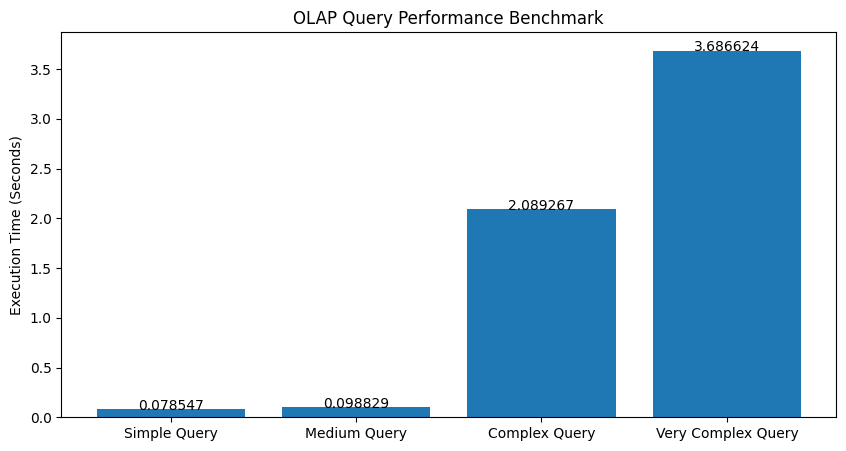

In [108]:
plt.figure(figsize=(10,5))

plt.bar(
    benchmark_df["Query Type"],
    benchmark_df["Execution Time (Seconds)"]
)

plt.title("OLAP Query Performance Benchmark")
plt.ylabel("Execution Time (Seconds)")

for i, v in enumerate(
    benchmark_df["Execution Time (Seconds)"]
):
    plt.text(
        i,
        v,
        str(v),
        ha="center"
    )

plt.show()